# Supercooled Profiles from MEOP Platform 9900109

Looking at all deployments (https://www.meop.net/database/meop-databases/meop-ctd-database.html), this MEOP platfomr was likely deployed during deployment ct40.

In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import scipy as sp
import mat73 # for loading .mat files version >= 7.3
from datetime import datetime, timedelta

# packages for plotting
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import cmocean.cm as cmo # ocean colormaps
from matplotlib.patches import Rectangle
from matplotlib import rc

# my own plotting functions
from obs_plotting_functions import *

In [2]:
# plotting settings
# plt.rcParams['text.usetex'] = True  # Latex muss installiert sein.
plt.rcParams['font.family'] = "sans-serif"
# rc('text.latex', preamble = r"\usepackage{amsmath}\usepackage{nicefrac}\usepackage{siunitx}")

## Load ERA5 Data

In [3]:
c_max = 0.99
filename = "ERA5_seaice_netHeat_leadHeat_cmax"+str(c_max)+".nc"
df_seaice = xr.open_dataset(filename)

# aggregate to daily means
df_seaice_daily = df_seaice.resample(time='D').mean(skipna=True)

# only 2008 data
df_seaice_2008 = df_seaice.sel(time=slice("2008-01-01", "2008-12-31"))

sh: getfattr: command not found


In [4]:
# sea ice animation
make_animation = False
if make_animation:
    fig = surface_animation(df_seaice_2008, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
    fig.write_html("animation.html")

## Load MEOP Data

In [5]:
filepath = "/isibhv/projects-noreplica/p_so-clim/alhaum001/supercool_profiles_merged_20200911.mat"
matstructs= mat73.loadmat(filepath) # this loads the matlab file as a python dictionary
matstructs.keys() # the dictionary keys (the names of the mat structures in the .mat file)

dict_keys(['data0', 'data1', 'data1_other', 'data2'])

In this Notebook, I look at supercooled MEOP / argofloat profiles from Haumann et al. (2020). The data is loaded from the file supercool_profiles_merged_20200911.mat. This file contains the following structures:
- data0: ?
- data1: metadata of the supercooled profiles
- data1_other: metadata of non-supercooled profiles
- data2: the supercooled profiles

In [6]:
data1 = matstructs['data1']
data1_other = matstructs['data1_other']
data2 = matstructs['data2']

### Add Datetime Variable to Data1 and Data1_other

In [7]:
# test datetime calculations
# we choose 0001-01-01 as test date

# in matlab, 0001-01-01 is day=367 (datenum(0001,1,1)=367 in matlab)
matlab_day = 367
zero_time = datetime(1,1,1) # this is the earliest time of datetime
day = matlab_day -1 - 366
date = zero_time + timedelta(days=day)
print(date)

0001-01-01 00:00:00


In [8]:
# add datetime variable
zero_time = datetime(1,1,1) # Matlab's day zero is 0000-01-01, but Python's datetime starts at 0001-01-01, so we need to account for that when converting

# DATA1
days = data1["dates"]-1-366 # convert from Matlab's datenum to number of days since 0001-01-01, accounting for the fact that Matlab's datenum starts with 1 at 0000-01-01 and includes a leap year in year 0
datetimes = [
    zero_time + timedelta(days=day) if day == day else float('nan') # convert to datetime, respecting NaN values
    for day in days
]

data1["datetimes"] = pd.Series(np.array(datetimes))

# DATA1_OTHER
days_other = data1_other["dates"]-1-366
datetimes_other = [
    zero_time + timedelta(days=day) if day == day else float('nan')
    for day in days_other
]

data1_other["datetimes"] = pd.Series(np.array(datetimes_other))


### Filter for Seal 9900109

In [9]:
mask_9900109 = (data1["id"] == 9900109)

data1_9900109 = {key: data1[key][mask_9900109] for key in data1.keys()}
data2_9900109 = {key: data2[key][:,mask_9900109] for key in data2.keys()}

mask_other_9900109 = (data1_other["id"] == 9900109)
data1_other_9900109 = {key: data1_other[key][mask_other_9900109] for key in data1_other.keys()}

print("Total number of profiles: ", len(data1_9900109["datetimes"])+len(data1_other_9900109["datetimes"]))
print("Number of supercooled profiles: ", len(data1_9900109["datetimes"]))
print("Number of profiles without supercooling: ", len(data1_other_9900109["datetimes"]))
print(f"Ratio: {len(data1_9900109["datetimes"])/(len(data1_9900109["datetimes"])+len(data1_other_9900109["datetimes"]))*100:.0f} %")

Total number of profiles:  620
Number of supercooled profiles:  209
Number of profiles without supercooling:  411
Ratio: 34 %


### Create Dataset of All Profiles from Seal 9900109 (both supercooled and not supercooled) - crop to study region & fall

In [10]:
# make dataframe with all profiles of this seal, both supercooled and not supercooled

# create empty dataframe
data1_9900109_all_df = pd.DataFrame()
data1_len = len(data1_9900109["dates"])
data1_other_len = len(data1_other_9900109["dates"])


for key in data1_9900109.keys():
    if key in data1_other_9900109.keys(): # for variables that exist in both data1 and data1_other just concatenate
        data1_9900109_all_df[key] = np.concatenate([data1_9900109[key], data1_other_9900109[key]])
    else: # otherwise insert values from and then fill up with nan
        nan_filler = np.full(shape = data1_other_len, fill_value = np.nan)
        data1_9900109_all_df[key] = np.concatenate([data1_9900109[key], nan_filler])

# ad SC flag
data1_9900109_all_df["SC"] = np.concatenate([np.full(shape=data1_len, fill_value = True), np.full(shape=data1_other_len, fill_value=False)])
data1_9900109_all_df["max_ps_all"] = np.concatenate([data1_9900109["max_ps"], np.full(shape = data1_other_len, fill_value = 0)])

# sort by dates
data1_9900109_all_df = data1_9900109_all_df.sort_values("dates")

# crop to june to sep 13 (after this the seal goes west of prime meridian)
mask_time = (data1_9900109_all_df.datetimes > datetime(2008,6,1)) &  (data1_9900109_all_df.datetimes < datetime(2008,9,14))
data1_9900109_all_df = data1_9900109_all_df.loc[mask_time, :]
data1_9900109_all_df = data1_9900109_all_df.reset_index(drop = True)

In [11]:
ntotal = len(data1_9900109_all_df.index)
nSC = data1_9900109_all_df.SC.sum()

print("Total number of profiles: ", ntotal)
print("Number of supercooled profiles: ", nSC)
print("Number of profiles without supercooling: ", ntotal-nSC)
print(f"Ratio: {nSC/ntotal*100:.0f} %")

Total number of profiles:  276
Number of supercooled profiles:  169
Number of profiles without supercooling:  107
Ratio: 61 %


### Add Sea Ice Conc and Lead Heat Flux

In [12]:
for i in range(len(data1_9900109_all_df.index)):
    temp = df_seaice.sel(time = data1_9900109_all_df.datetimes.values[i], latitude = data1_9900109_all_df.lat.values[i], longitude = data1_9900109_all_df.lon.values[i], method = "nearest")
    data1_9900109_all_df.loc[i,"siconc"] = temp.siconc.values
    data1_9900109_all_df.loc[i,"open_water_heatflux"] = temp.open_water_heatflux.values
    data1_9900109_all_df.loc[i,"surface_net_heat_flux"] = temp.surface_net_heat_flux.values
    
data1_9900109_all_df

,bath,bot,bot_ps,cycle,dates,dcycle,ddates,f,flag,heat_ps,...,surf,surf_ps,thickn_ps,types,datetimes,SC,max_ps_all,siconc,open_water_heatflux,surface_net_heat_flux
0,NaN,NaN,NaN,283.0,733560.152778,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,2008-06-01 03:39:59.999998,False,0.000000,0.000000,-3.998993,-3.998993
1,NaN,NaN,NaN,284.0,733560.569444,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,2008-06-01 13:40:00.000004,False,0.000000,0.000000,-18.731445,-18.731445
2,NaN,NaN,NaN,285.0,733560.812500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,2008-06-01 19:30:00.000000,False,0.000000,0.000000,-15.478516,-15.478516
3,NaN,NaN,NaN,286.0,733561.055556,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,2008-06-02 01:19:59.999996,False,0.000000,0.000000,-40.178635,-40.178635
4,NaN,NaN,NaN,287.0,733561.354167,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,2008-06-02 08:29:59.999997,False,0.000000,0.000000,-32.434326,-32.434326
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271,4561.00,797.154534,35.671045,556.0,733662.569444,NaN,NaN,-0.00012,0.0,-4.490308e+06,...,5.945607,5.945607,29.725438,3.0,2008-09-11 13:40:00.000004,True,-0.028480,0.694275,-243.904175,-74.567627
272,5052.50,601.617649,106.004840,557.0,733663.076389,NaN,NaN,-0.00012,0.0,-4.403538e+07,...,5.945653,5.945653,100.059187,3.0,2008-09-12 01:49:59.999999,True,-0.128421,0.744659,-97.396019,-24.869156
273,5043.00,627.309076,110.957615,558.0,733663.319444,NaN,NaN,-0.00012,0.0,-5.079252e+07,...,5.945687,5.945687,105.011929,3.0,2008-09-12 07:40:00.000004,True,-0.129160,0.750824,100.418861,25.021973
274,4740.75,532.451474,104.025793,559.0,733663.840278,NaN,NaN,-0.00012,0.0,-3.599469e+07,...,5.945759,5.945759,98.080034,3.0,2008-09-12 20:09:59.999998,True,-0.098106,0.750824,-455.059387,-113.389893


## Map View

In [13]:
data1_9900109_all_df["mld"].max()

np.float64(141.64456119375401)

### Max Pot SC

In [14]:
data1_other.keys()

dict_keys(['cycle', 'dates', 'id', 'id2', 'lat', 'lon', 'types', 'datetimes'])

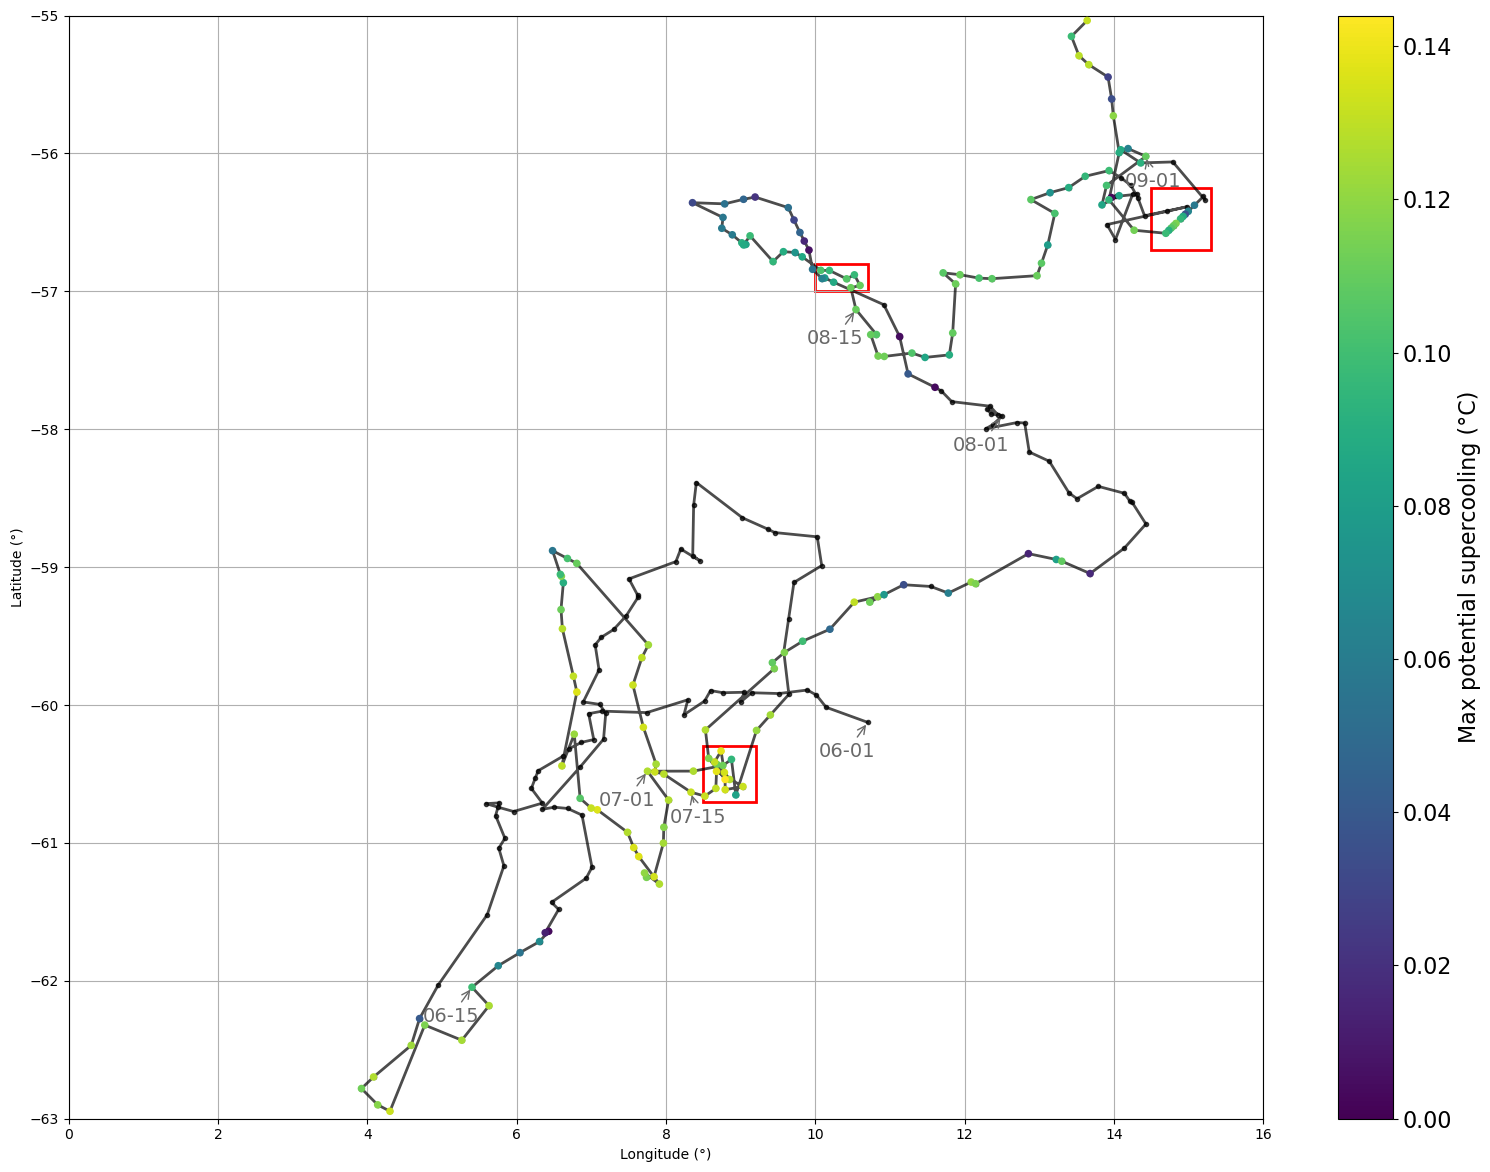

In [15]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
fig, ax = plt.subplots(figsize=(16, 12))
plt.rcParams['font.size'] = 16

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=-data1_9900109_all_df["max_ps"], cmap='viridis', 
                      s=30, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 0.144)


# cluster rectangles
rect09 = Rectangle((14.5, -56.7), 0.8, 0.45, linewidth=2, edgecolor='red', facecolor='none')
rect08 = Rectangle((10, -57), 0.7, 0.2, linewidth=2, edgecolor='red', facecolor='none')
rect07 = Rectangle((8.5, -60.7), 0.7, 0.4, linewidth=2, edgecolor='red', facecolor='none')



# Add the rectangles to the axis
ax.add_patch(rect09)
ax.add_patch(rect08)
ax.add_patch(rect07)


# Annotate points with time
seen_dates = [] # to track that every day label appears only once
for i, row in data1_9900109_all_df.iterrows():
    date = row['datetimes'].date()
    day = date.day
    if date not in seen_dates:
        seen_dates.append(date)
        # Only annotate if it's the 1st, 6th, 11th, etc. day (every 5th starting at 0)
        if day in (1,15):
            if date.strftime('%m-%d') in ["07-15", "09-01"]: # 09-01 & 07-15 need other alignment
                x = 5
                y = -22
            else:
                x = -15
                y = -25
            plt.annotate(row['datetimes'].strftime('%m-%d'), 
                         (row['lon'], row['lat']), 
                         textcoords="offset points", xytext=(x,y), 
                         ha='center', fontsize=14, zorder=4, color = "dimgrey",
                         arrowprops=dict(arrowstyle='->', color='dimgrey'))

# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max potential supercooling (°C)')

# Label axes
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
# plt.title('Seal 9900109 Maxi Pot SC - June to September')

plt.xlim(0,16)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

### Max SC Depth

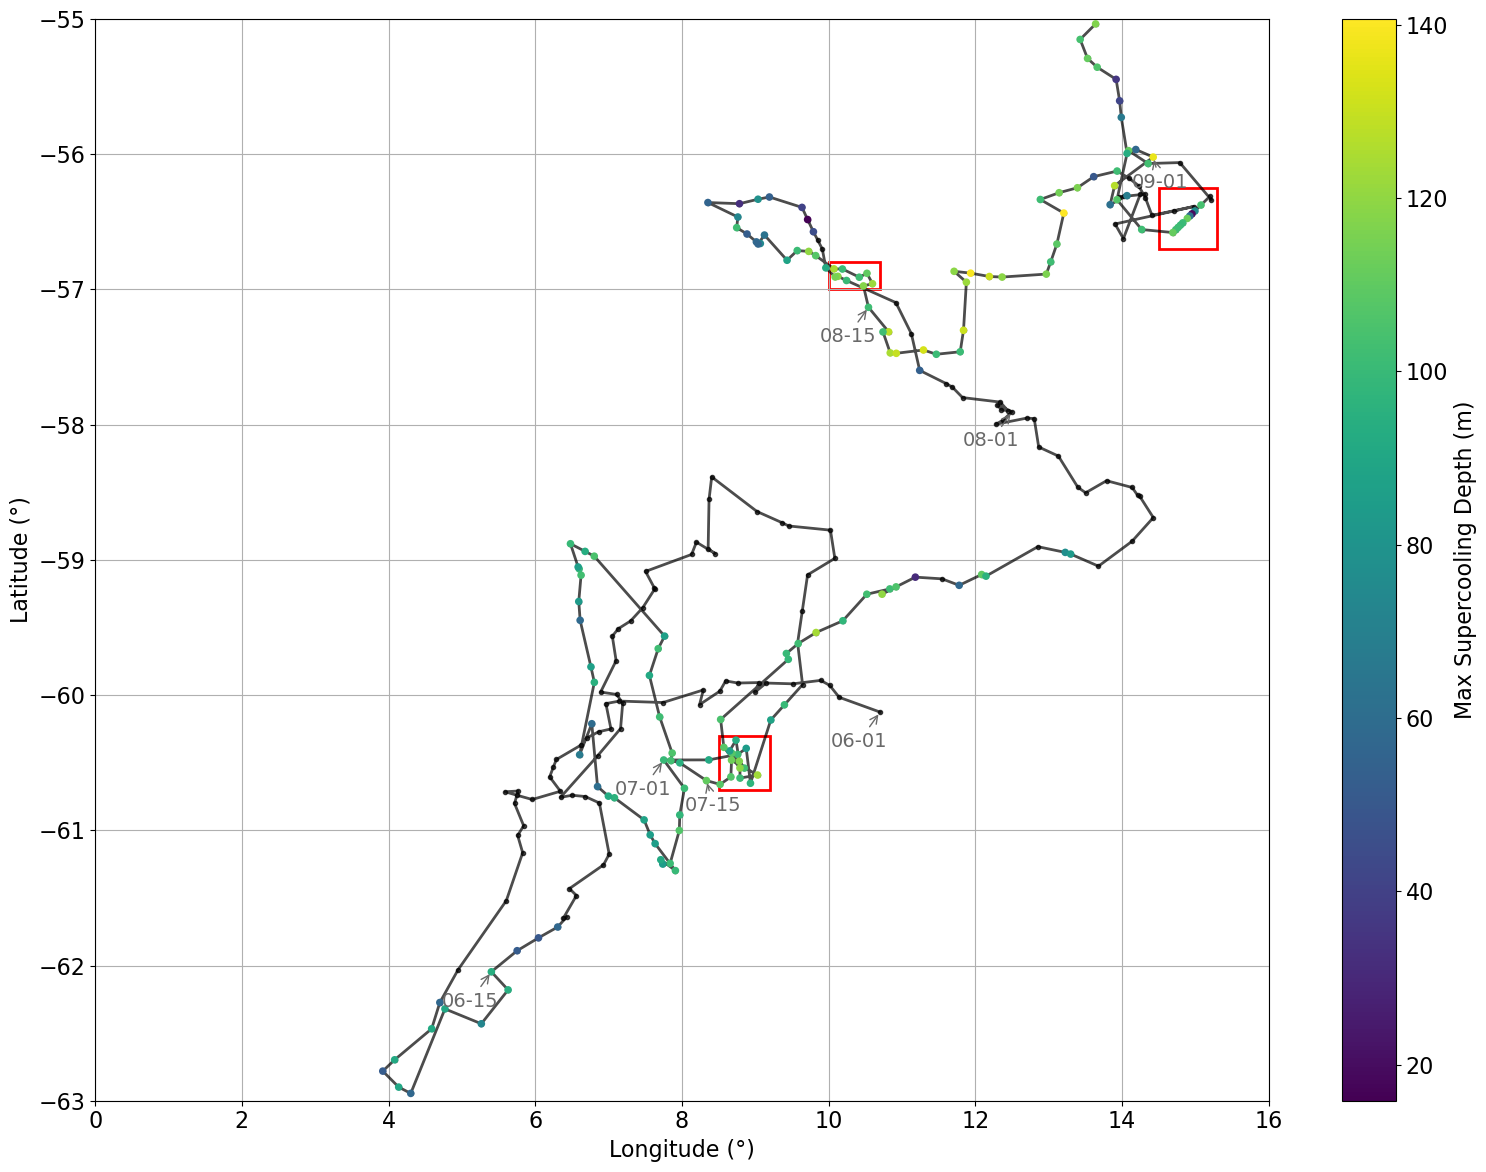

In [16]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
fig, ax = plt.subplots(figsize=(16, 12))
plt.rcParams['font.size'] = 16

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c=data1_9900109_all_df["bot_ps"], cmap='viridis', 
                      s=30, edgecolors='none', zorder=3, label='Locations')


# cluster rectangles
rect09 = Rectangle((14.5, -56.7), 0.8, 0.45, linewidth=2, edgecolor='red', facecolor='none')
rect08 = Rectangle((10, -57), 0.7, 0.2, linewidth=2, edgecolor='red', facecolor='none')
rect07 = Rectangle((8.5, -60.7), 0.7, 0.4, linewidth=2, edgecolor='red', facecolor='none')



# Add the rectangles to the axis
ax.add_patch(rect09)
ax.add_patch(rect08)
ax.add_patch(rect07)


# Annotate points with time
seen_dates = [] # to track that every day label appears only once
for i, row in data1_9900109_all_df.iterrows():
    date = row['datetimes'].date()
    day = date.day
    if date not in seen_dates:
        seen_dates.append(date)
        # Only annotate if it's the 1st, 6th, 11th, etc. day (every 5th starting at 0)
        if day in (1,15):
            if date.strftime('%m-%d') in ["07-15", "09-01"]: # 09-01 & 07-15 need other alignment
                x = 5
                y = -22
            else:
                x = -15
                y = -25
            plt.annotate(row['datetimes'].strftime('%m-%d'), 
                         (row['lon'], row['lat']), 
                         textcoords="offset points", xytext=(x,y), 
                         ha='center', fontsize=14, zorder=4, color = "dimgrey",
                         arrowprops=dict(arrowstyle='->', color='dimgrey'))

# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max Supercooling Depth (m)')

# Label axes
plt.xlabel('Longitude (°)')
plt.ylabel('Latitude (°)')
# plt.title('Seal 9900109 Maxi Pot SC - June to September')

plt.xlim(0,16)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

### MLD Penetration

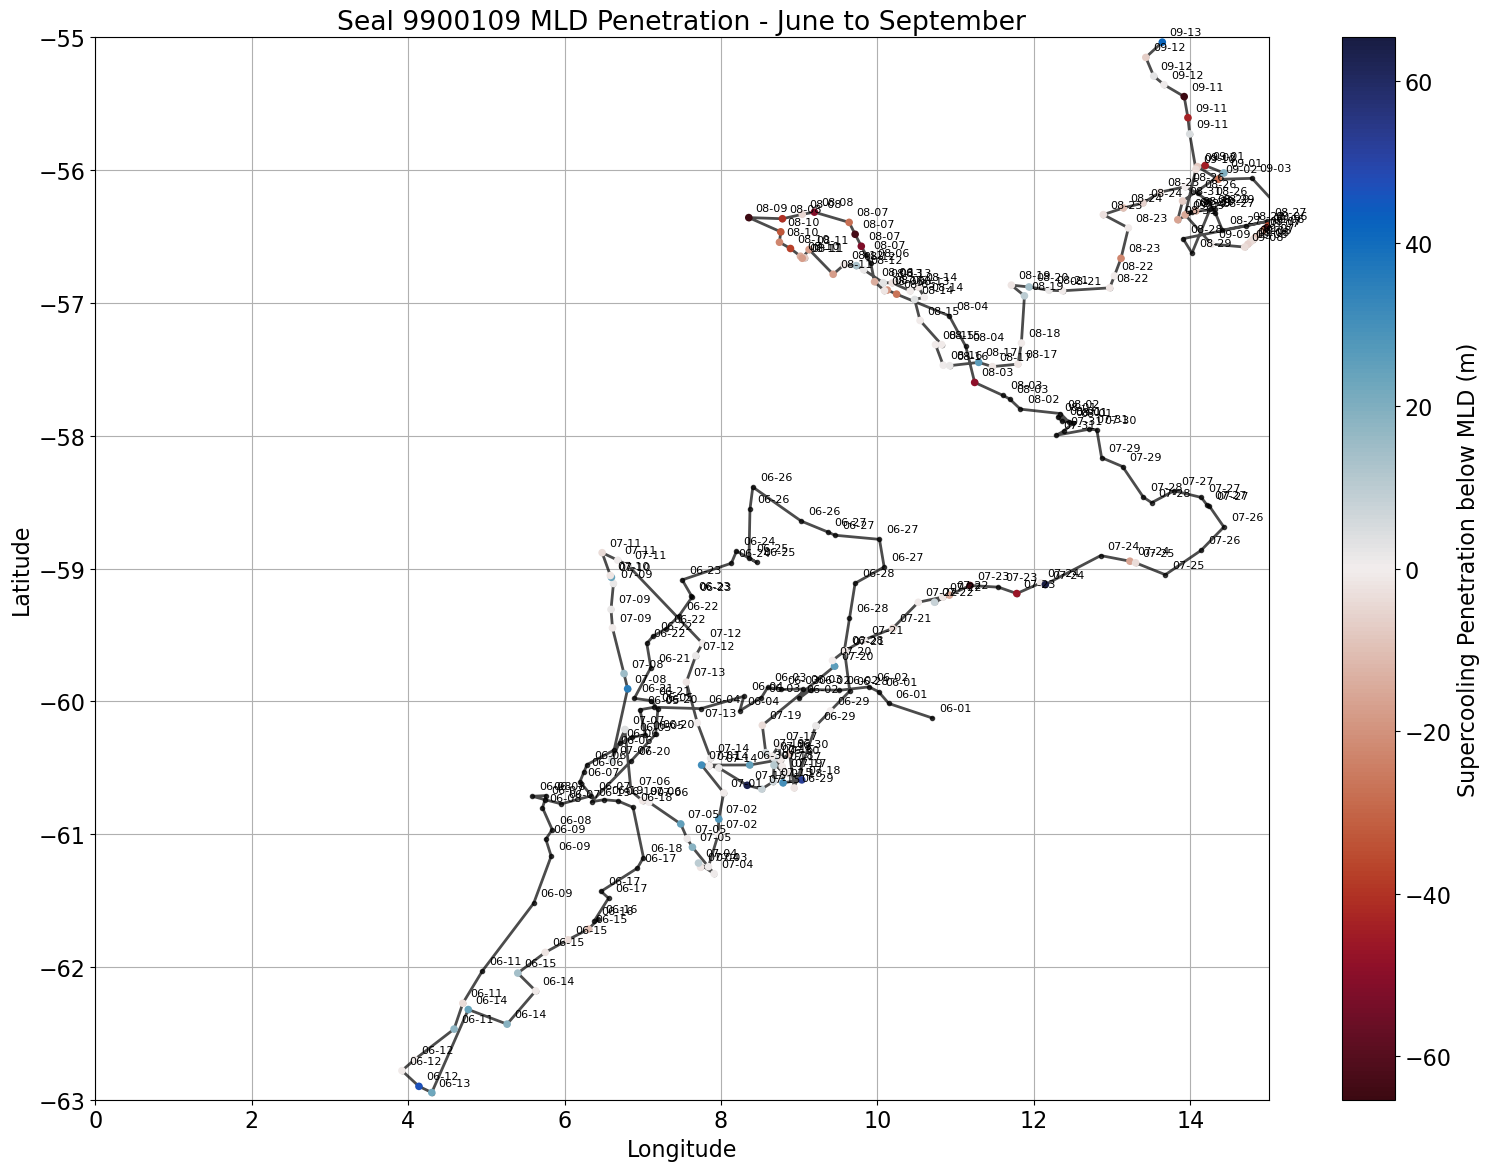

In [17]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# Draw the path line
plt.plot(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "black")


# Add scatter points with SC coloring
mld_penetration = data1_9900109_all_df["bot_ps"] - data1_9900109_all_df["mld"]
max_mld_pen = np.nanmax(mld_penetration)

scatter = plt.scatter(data1_9900109_all_df['lon'], data1_9900109_all_df['lat'], c = mld_penetration, cmap=cmo.balance.reversed(), vmin = -max_mld_pen, vmax = max_mld_pen,
                      s=30, edgecolors='none', zorder=3, label='Locations')


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Supercooling Penetration below MLD (m)')

# Annotate points with time
for i, row in data1_9900109_all_df.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4)

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 MLD Penetration - June to September')

plt.xlim(0,15)
plt.ylim(-63,-55)

plt.grid(True)
plt.tight_layout()
plt.show()

## Cluster

### July Cluster 07-16 08 to 07-19 11:00

In [18]:
start_date07 = pd.to_datetime("2008-07-16 08:00")
end_date07 = pd.to_datetime("2008-07-19 12:00")

# MEOP data in this cluster
# Data1
mask = (data1_9900109_all_df['datetimes'] >= start_date07) & (data1_9900109_all_df['datetimes'] <= end_date07)
data1_all_cluster07 = data1_9900109_all_df[mask]
# Data2
mask_9900109 = (data1["id"] == 9900109)
mask_time = (data1["datetimes"] < end_date07) & (data1["datetimes"] > start_date07)
mask_final = mask_9900109 & mask_time
cluster07_data2 = {key: data2[key][:,mask_final] for key in data2.keys()}
cluster07_data2_datetimes = data1["datetimes"][mask_final]

# sea ice concentration for the whole grid during the cluster time
df_seaice_cluster07 = df_seaice.sel(time=slice(start_date07, end_date07))
make_animation = False
if make_animation:
    fig = surface_animation(df_seaice_cluster07, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
    fig.write_html("seaice_animation_cluster07.html")
# cluster average
df_seaice_cluster07_mean = df_seaice_cluster07.mean("time")

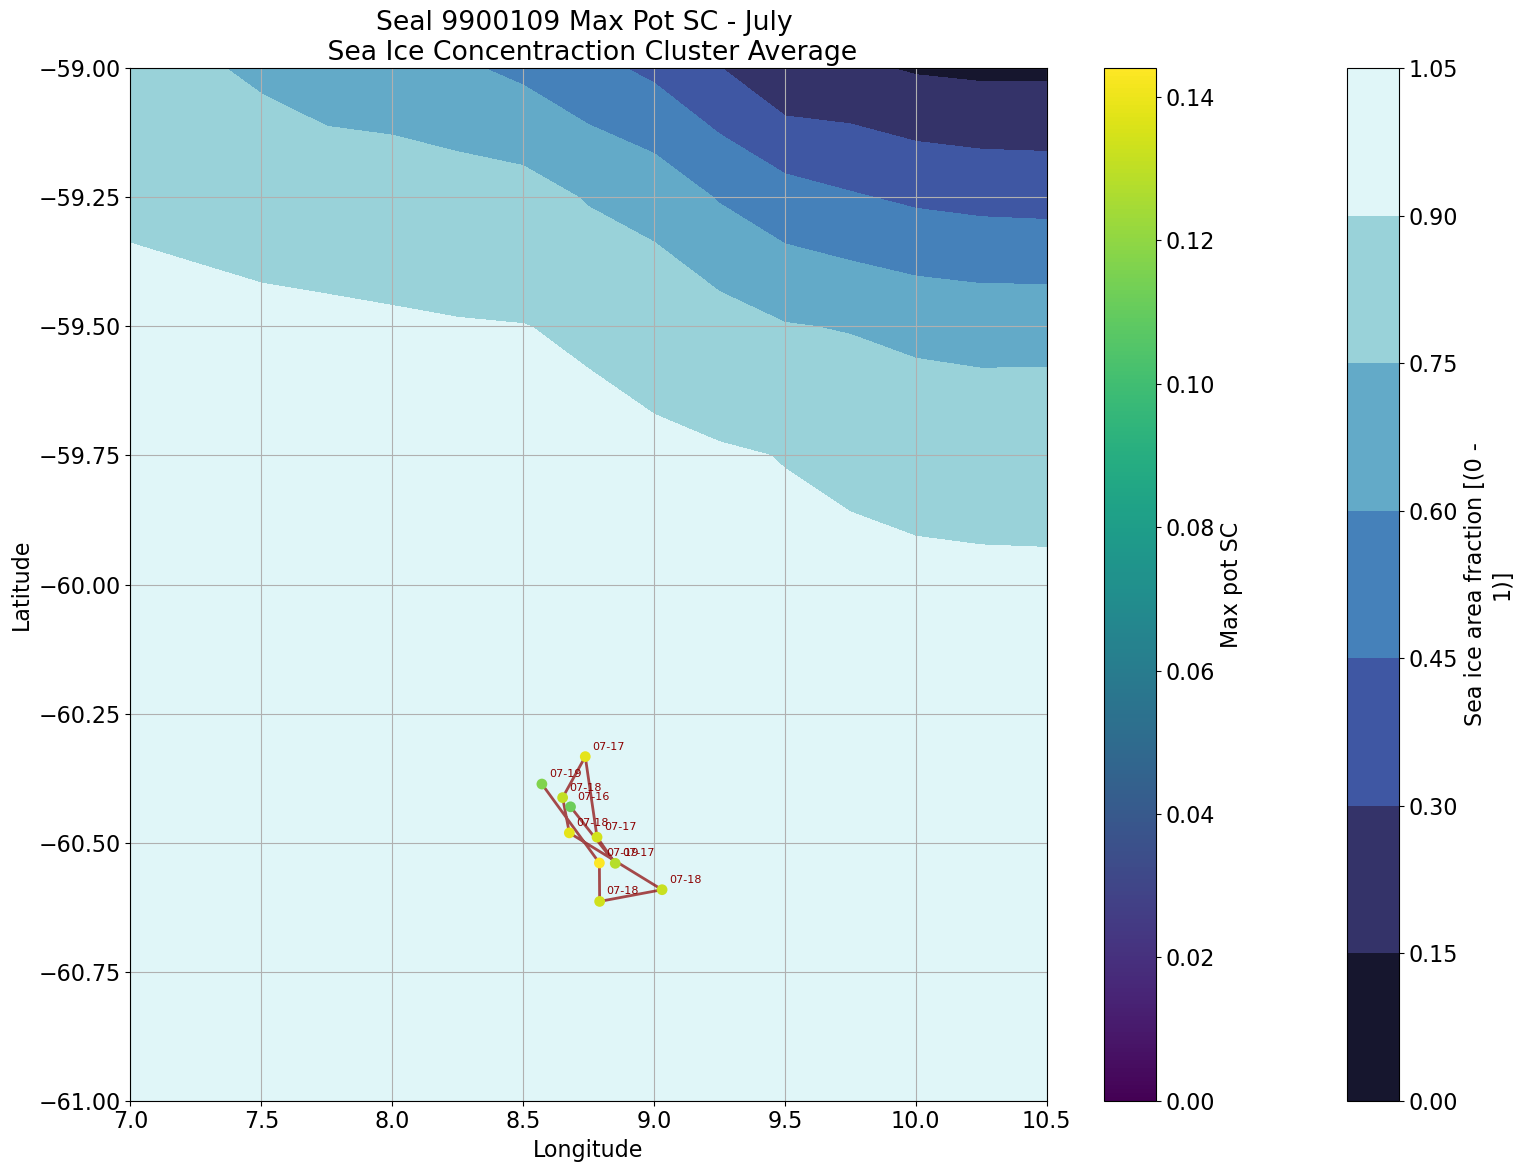

In [19]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# plot sea ice concentration
df_seaice_cluster07.siconc.isel(time = -1).plot.contourf(cmap = cmo.ice, vmin = 0, vmax = 1)

# Draw the path line
plt.plot(data1_all_cluster07['lon'], data1_all_cluster07['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "darkred")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_all_cluster07['lon'], data1_all_cluster07['lat'], c=-data1_all_cluster07["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 0.144)

# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_all_cluster07.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4, color = "darkred")

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - July \n Sea Ice Concentraction Cluster Average')

# plt.xlim(6,9.5) # big july view
# plt.ylim(-61.5, -59) # big july view

plt.xlim(7,10.5)
plt.ylim(-61, -59)

plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Profile Depth')

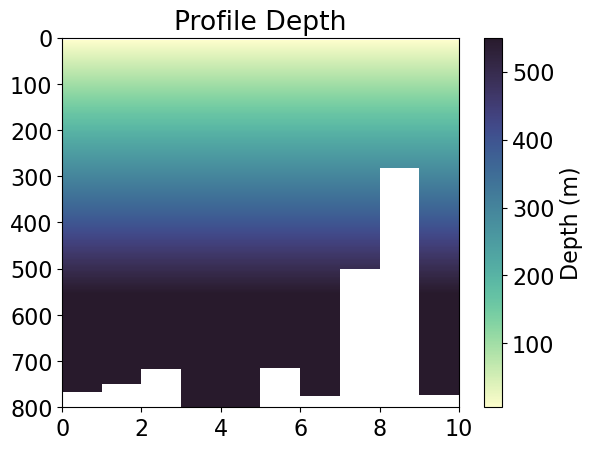

In [20]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(cluster07_data2["dpth"], vmax = 550, cmap = cmo.deep)

# ax.pcolormesh(cluster_data2_datetimes, cluster_data2["dpth"], cluster_data2["def_pt0"])

ax.set_ylim(800,0)

# make colorbar
fig.colorbar(pcm, label = "Depth (m)")
plt.title("Profile Depth")

/tmp/ipykernel_16280/1127353081.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax[0].pcolormesh(cluster07_data2_datetimes, depth, cluster07_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
/tmp/ipykernel_16280/1127353081.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm_iS = ax[1].pcolormesh(cluster07_data2_datetimes, depth, cluster07_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)


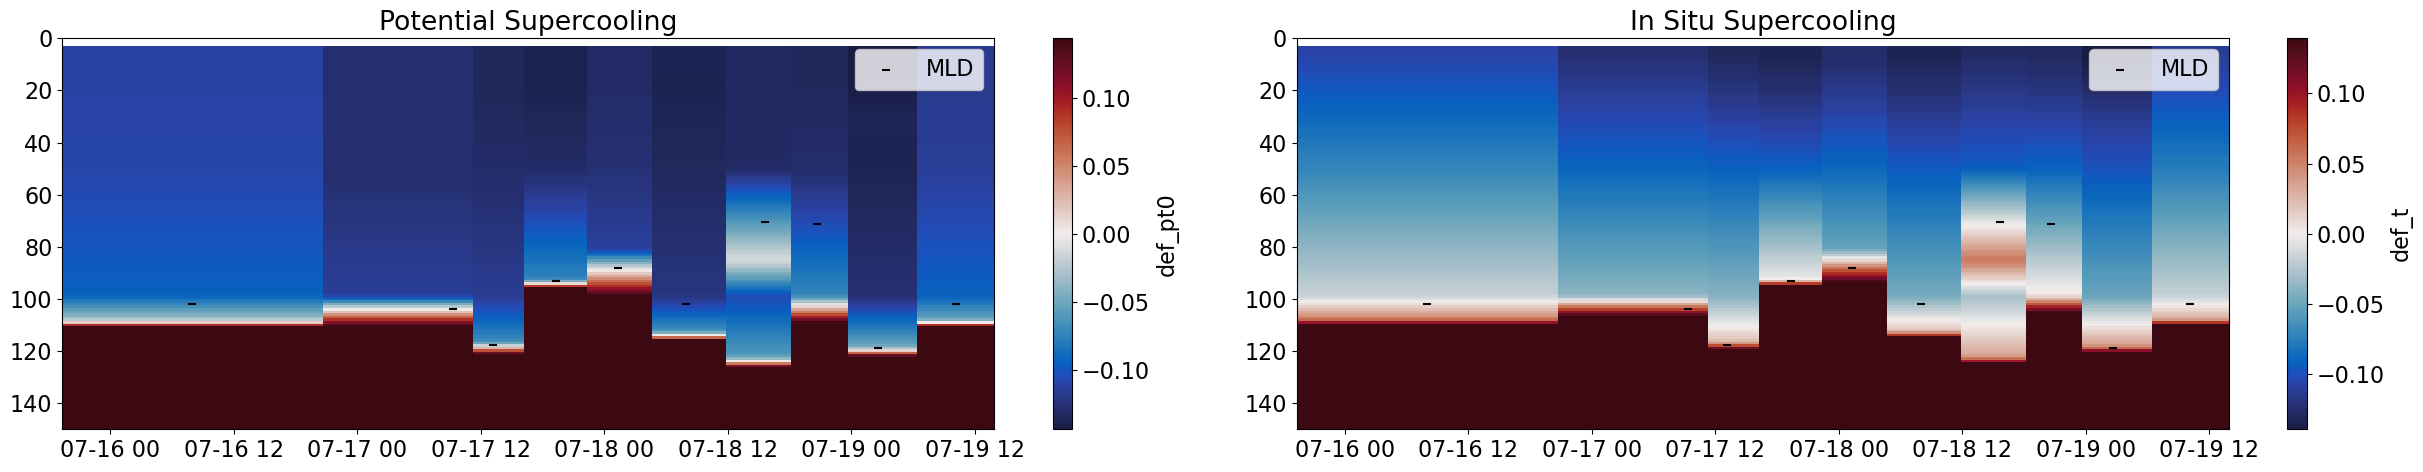

In [21]:
fig, ax = plt.subplots(1,2, figsize = (25,5))

depth = np.nan_to_num(cluster07_data2["dpth"], nan = 0)

# plot potential SC
max_SC = np.nanmin(cluster07_data2["def_pt0"])
pcm = ax[0].pcolormesh(cluster07_data2_datetimes, depth, cluster07_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[0].scatter(data1_all_cluster07["datetimes"], data1_all_cluster07["mld"], marker = "_", color = "black", label = "MLD")

# plot in situ SC
max_SC = np.nanmin(cluster07_data2["def_t"])
pcm_iS = ax[1].pcolormesh(cluster07_data2_datetimes, depth, cluster07_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[1].scatter(data1_all_cluster07["datetimes"], data1_all_cluster07["mld"], marker = "_", color = "black", label = "MLD")

ax[0].set_ylim(150,0)
ax[1].set_ylim(150,0)

ax[0].set_title("Potential Supercooling")
ax[1].set_title("In Situ Supercooling")

ax[0].legend(loc = "upper right")
ax[1].legend(loc = "upper right")

# make colorbar
fig.colorbar(pcm, label = "def_pt0")
fig.colorbar(pcm_iS, label = "def_t")

fig.tight_layout()


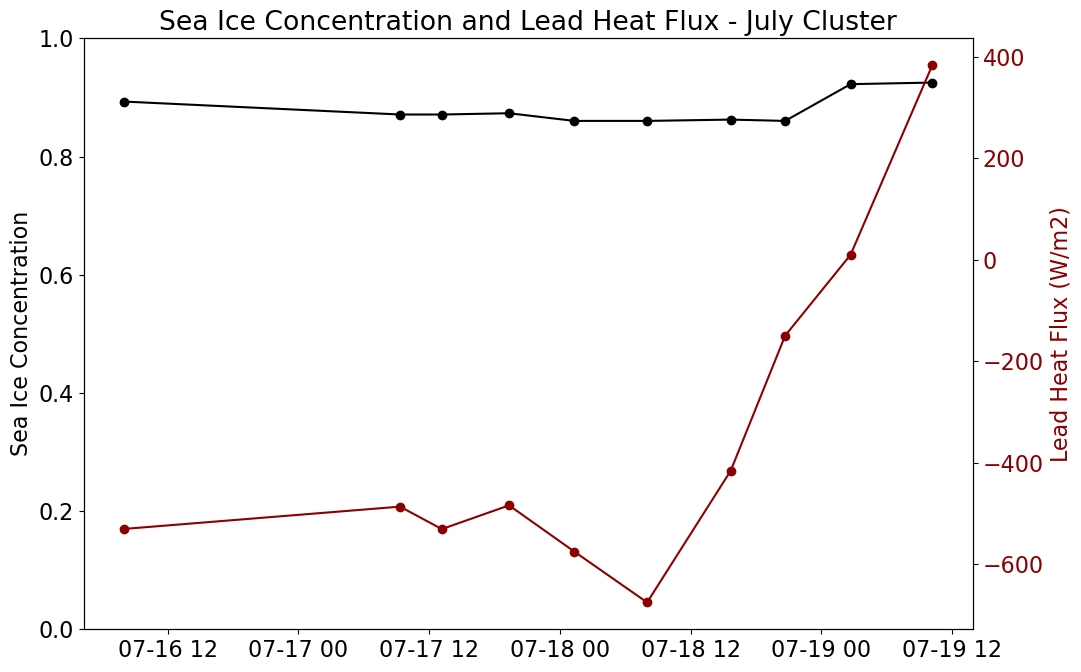

In [22]:
fig, ax = plt.subplots(figsize = (11.1,7))

ax.plot(data1_all_cluster07.datetimes, data1_all_cluster07.siconc, "-o",color = "black")
ax.set_ylabel("Sea Ice Concentration")
ax.set_ylim(0,1)

ax2col = "darkred"
ax2 = ax.twinx()
ax2.plot(data1_all_cluster07.datetimes, data1_all_cluster07.open_water_heatflux, "-o",color =ax2col)
ax2.set_ylabel("Lead Heat Flux (W/m2)", color=ax2col)
ax2.tick_params(axis='y', labelcolor=ax2col)

plt.title("Sea Ice Concentration and Lead Heat Flux - July Cluster")
plt.tight_layout()


### August Cluster 08-13 to 08-14

In [23]:
start_date08 = pd.to_datetime("2008-08-13 00:00")
end_date08 = pd.to_datetime("2008-08-14 23:00")

# MEOP data in this cluster
# Data1
mask = (data1_9900109_all_df['datetimes'] >= start_date08) & (data1_9900109_all_df['datetimes'] <= end_date08)
data1_all_cluster08 = data1_9900109_all_df[mask]
# Data2
mask_9900109 = (data1["id"] == 9900109)
mask_time = (data1["datetimes"] < end_date08) & (data1["datetimes"] > start_date08)
mask_final = mask_9900109 & mask_time
cluster08_data2 = {key: data2[key][:,mask_final] for key in data2.keys()}
cluster08_data2_datetimes = data1["datetimes"][mask_final]

# sea ice concentration for the whole grid during the cluster time
df_seaice_cluster08 = df_seaice.sel(time=slice(start_date08, end_date08))
make_animation = False
if make_animation:
    fig = surface_animation(df_seaice_cluster08, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
    fig.write_html("seaice_animation_cluster08.html")
# cluster average
df_seaice_cluster08_mean = df_seaice_cluster08.mean("time")


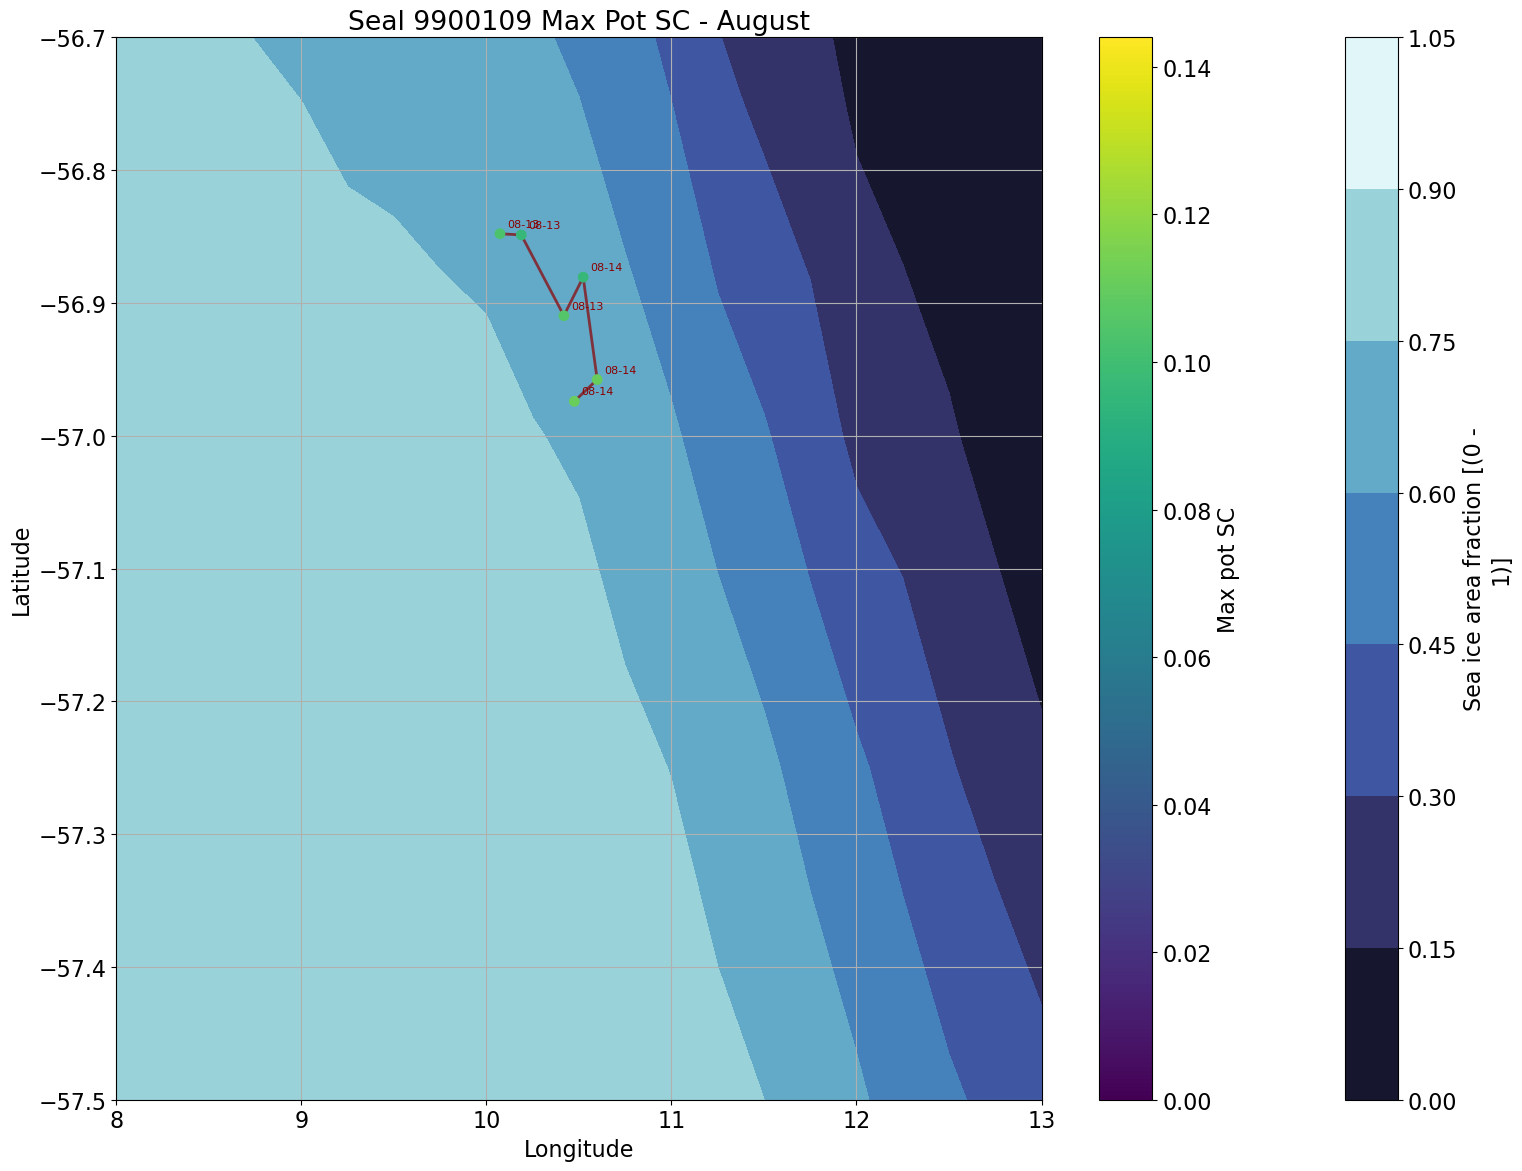

In [24]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# plot sea ice concentration
df_seaice_cluster08_mean.siconc.plot.contourf(cmap = cmo.ice, vmin = 0, vmax = 1, zorder = 1)

# Draw the path line
plt.plot(data1_all_cluster08['lon'], data1_all_cluster08['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "darkred")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_all_cluster08['lon'], data1_all_cluster08['lat'], c=-data1_all_cluster08["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 0.144)


# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_all_cluster08.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4, color = "darkred")

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - August')

plt.xlim(8,13)
plt.ylim(-57.5,-56.7)

plt.grid(True)
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Profile Depth')

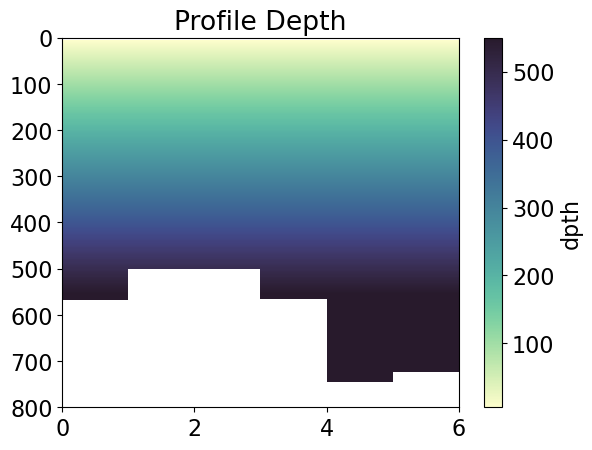

In [25]:
fig, ax = plt.subplots()

pcm = ax.pcolormesh(cluster08_data2["dpth"], vmax = 550, cmap = cmo.deep)

# ax.pcolormesh(cluster_data2_datetimes, cluster_data2["dpth"], cluster_data2["def_pt0"])

ax.set_ylim(800,0)

# make colorbar
fig.colorbar(pcm, label = "dpth")
plt.title("Profile Depth")

/tmp/ipykernel_16280/3568296873.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax[0].pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
/tmp/ipykernel_16280/3568296873.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm_iS = ax[1].pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)


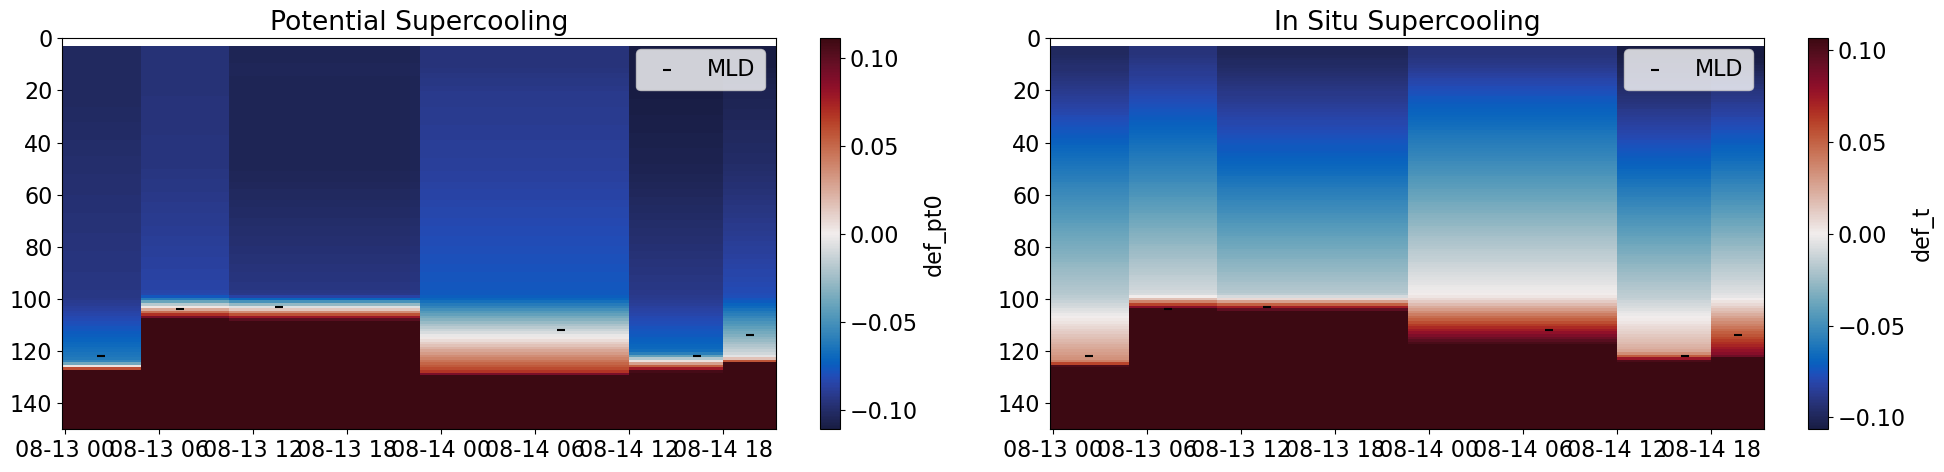

In [26]:
fig, ax = plt.subplots(1,2, figsize = (20,5))

depth = np.nan_to_num(cluster08_data2["dpth"], nan = 0)

# plot potential SC
max_SC = np.nanmin(cluster08_data2["def_pt0"])
pcm = ax[0].pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[0].scatter(data1_all_cluster08["datetimes"], data1_all_cluster08["mld"], marker = "_", color = "black", label = "MLD")

# plot in situ SC
max_SC = np.nanmin(cluster08_data2["def_t"])
pcm_iS = ax[1].pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[1].scatter(data1_all_cluster08["datetimes"], data1_all_cluster08["mld"], marker = "_", color = "black", label = "MLD")

ax[0].set_ylim(150,0)
ax[1].set_ylim(150,0)

ax[0].set_title("Potential Supercooling")
ax[1].set_title("In Situ Supercooling")

ax[0].legend(loc = "upper right")
ax[1].legend(loc = "upper right")

# make colorbar
fig.colorbar(pcm, label = "def_pt0")
fig.colorbar(pcm_iS, label = "def_t")

fig.tight_layout()

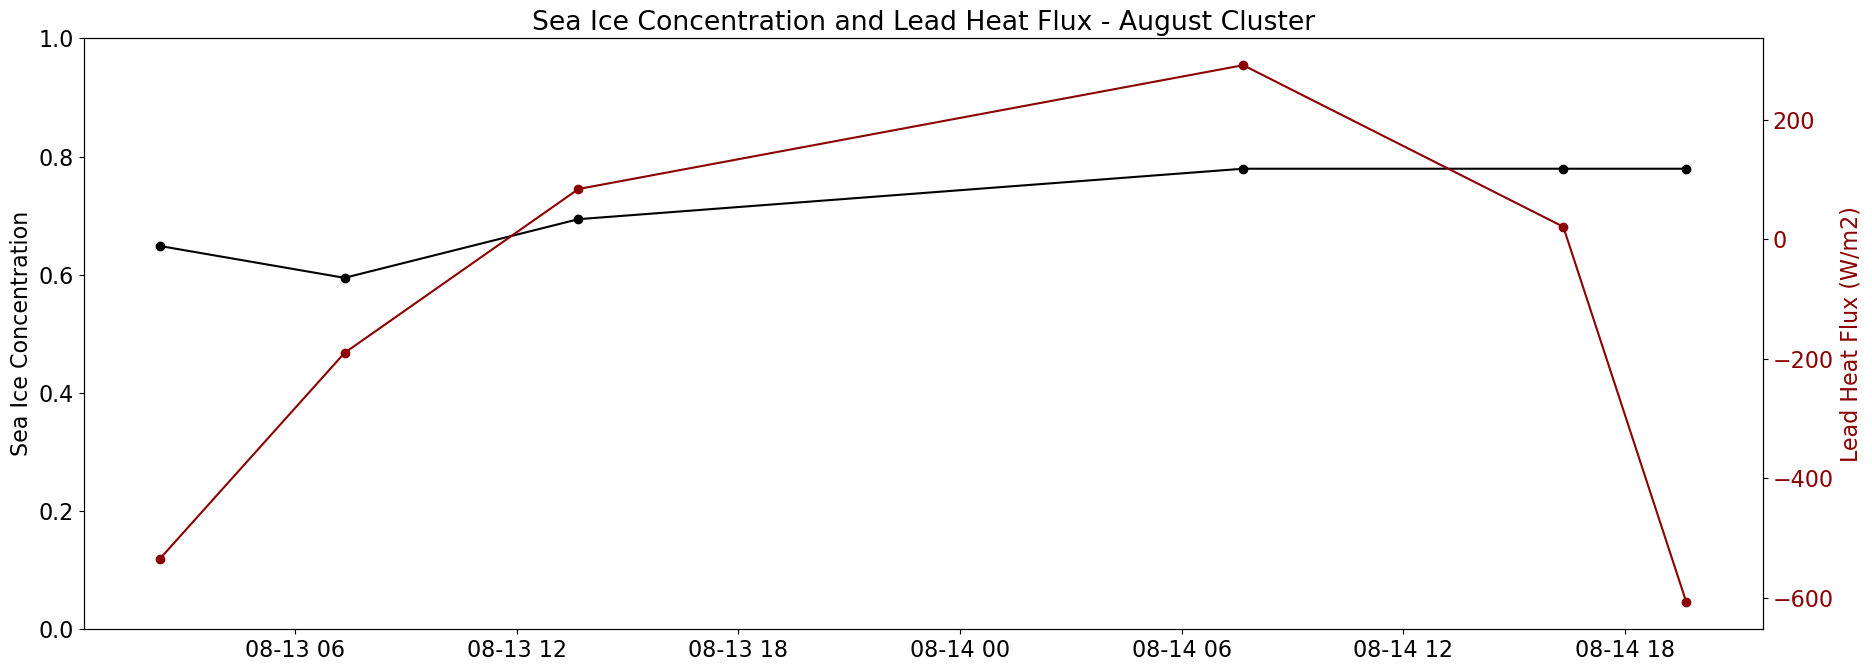

In [27]:
fig, ax = plt.subplots(figsize = (19,7))

ax.plot(data1_all_cluster08.datetimes, data1_all_cluster08.siconc, "-o", color = "black")
ax.set_ylabel("Sea Ice Concentration")
ax.set_ylim(0,1)

ax2col = "darkred"
ax2 = ax.twinx()
ax2.plot(data1_all_cluster08.datetimes, data1_all_cluster08.open_water_heatflux, "-o", color =ax2col)
ax2.set_ylabel("Lead Heat Flux (W/m2)", color=ax2col)
ax2.tick_params(axis='y', labelcolor=ax2col)

plt.title("Sea Ice Concentration and Lead Heat Flux - August Cluster")
plt.tight_layout()

/tmp/ipykernel_16280/1543911977.py:5: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["pt0"], cmap = cmo.thermal)


Text(0.5, 1.0, 'Potential Temperature')

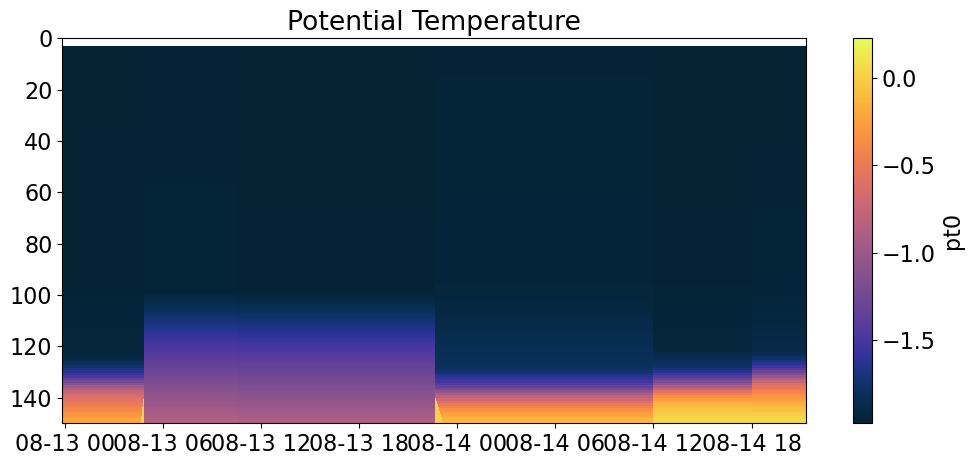

In [28]:
fig, ax = plt.subplots(figsize = (12,5))

depth = np.nan_to_num(cluster08_data2["dpth"], nan = 0)

pcm = ax.pcolormesh(cluster08_data2_datetimes, depth, cluster08_data2["pt0"], cmap = cmo.thermal)

ax.set_ylim(150,0)

# make colorbar
fig.colorbar(pcm, label = "pt0")
plt.title("Potential Temperature")

### September Cluster 09-05 to 09-08

In [29]:
start_date09 = pd.to_datetime("2008-09-05 20:00")
end_date09 = pd.to_datetime("2008-09-08 21:00")

# MEOP data in this cluster
# Data1
mask = (data1_9900109_all_df['datetimes'] >= start_date09) & (data1_9900109_all_df['datetimes'] <= end_date09)
data1_all_cluster09 = data1_9900109_all_df[mask]
# Data2
mask_9900109 = (data1["id"] == 9900109)
mask_time = (data1["datetimes"] < end_date09) & (data1["datetimes"] > start_date09)
mask_final = mask_9900109 & mask_time
cluster09_data2 = {key: data2[key][:,mask_final] for key in data2.keys()}
cluster09_data2_datetimes = data1["datetimes"][mask_final]

# sea ice concentration for the whole grid during the cluster time
df_seaice_cluster09 = df_seaice.sel(time=slice(start_date09, end_date09))
make_animation = False
if make_animation:
    fig = surface_animation(df_seaice_cluster09, "siconc", "ERA5", "time", "longitude", "latitude", "ice")
    fig.write_html("seaice_animation_cluster09.html")
# cluster average
df_seaice_cluster09_mean = df_seaice_cluster09.mean("time")
df_seaice_cluster09_mean = df_seaice.sel(time = end_date09)


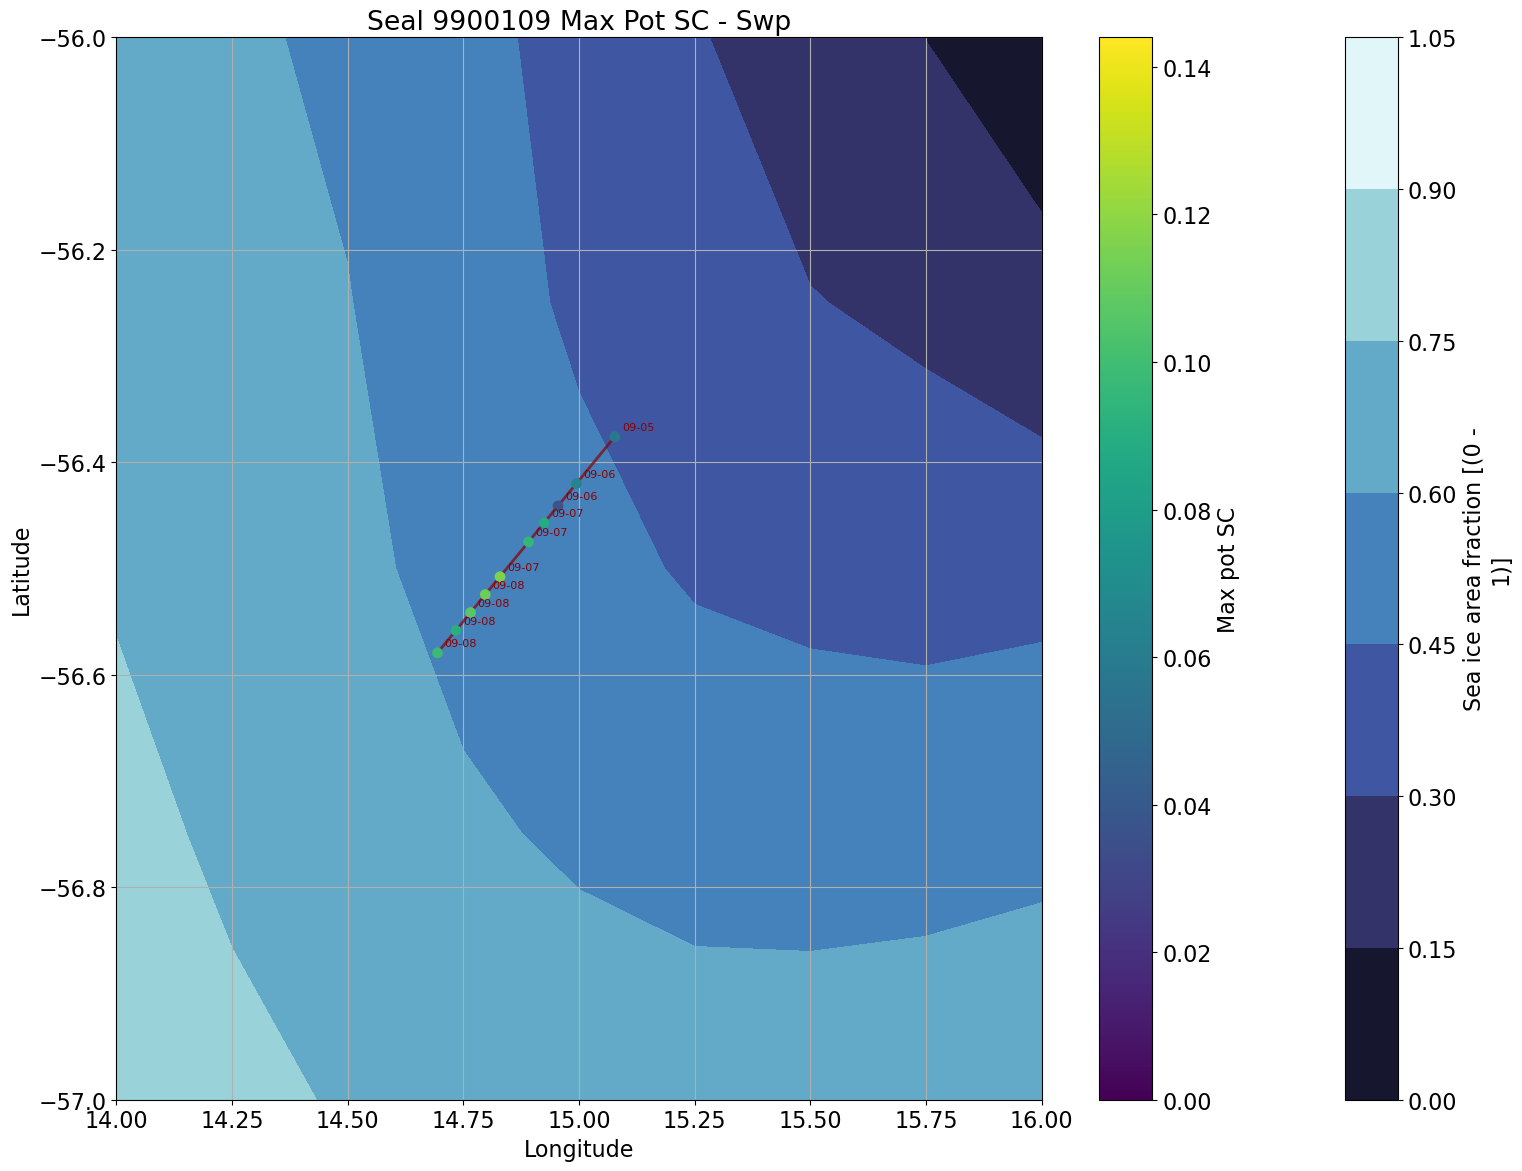

In [30]:
# MOVEMENT OF SEAL WITH MAX POT SC

# Plot
plt.figure(figsize=(16, 12))

# plot sea ice concentration
df_seaice_cluster09.siconc.isel(time=0).plot.contourf(cmap = cmo.ice, vmin = 0, vmax = 1)

# Draw the path line
plt.plot(data1_all_cluster09['lon'], data1_all_cluster09['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "darkred")


# Add scatter points with SC coloring
scatter = plt.scatter(data1_all_cluster09['lon'], data1_all_cluster09['lat'], c=-data1_all_cluster09["max_ps"], cmap='viridis', 
                      s=60, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 0.144)

# Apply the formatter to the colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Max pot SC')

# Annotate points with time
for i, row in data1_all_cluster09.iterrows():
    plt.annotate(row['datetimes'].strftime('%m-%d'), (row['lon'], row['lat']), 
                 textcoords="offset points", xytext=(5,5), ha='left', fontsize=8, zorder=4, color = "darkred")

# Label axes
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seal 9900109 Max Pot SC - Swp')

plt.xlim(14,16)
plt.ylim(-57,-56)

plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_16280/922966751.py:7: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax[0].pcolormesh(cluster09_data2_datetimes, depth, cluster09_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
/tmp/ipykernel_16280/922966751.py:13: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm_iS = ax[1].pcolormesh(cluster09_data2_datetimes, depth, cluster09_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)


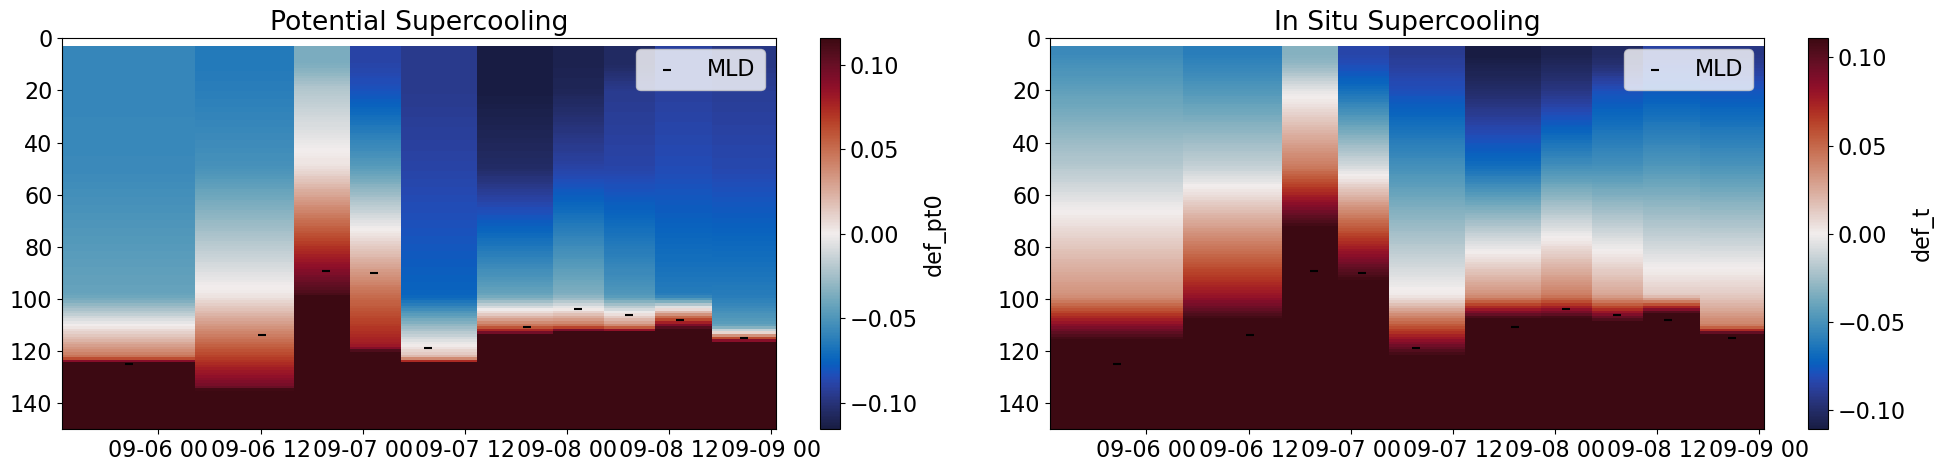

In [31]:
fig, ax = plt.subplots(1,2, figsize = (20,5))

depth = np.nan_to_num(cluster09_data2["dpth"], nan = 0)

# plot potential SC
max_SC = np.nanmin(cluster09_data2["def_pt0"])
pcm = ax[0].pcolormesh(cluster09_data2_datetimes, depth, cluster09_data2["def_pt0"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[0].scatter(data1_all_cluster09["datetimes"], data1_all_cluster09["mld"], marker = "_", color = "black", label = "MLD")

# plot in situ SC
max_SC = np.nanmin(cluster09_data2["def_t"])
pcm_iS = ax[1].pcolormesh(cluster09_data2_datetimes, depth, cluster09_data2["def_t"], cmap = cmo.balance, vmin = max_SC, vmax = -max_SC)
# add MLD
ax[1].scatter(data1_all_cluster09["datetimes"], data1_all_cluster09["mld"], marker = "_", color = "black", label = "MLD")

ax[0].set_ylim(150,0)
ax[1].set_ylim(150,0)

ax[0].set_title("Potential Supercooling")
ax[1].set_title("In Situ Supercooling")

ax[0].legend(loc = "upper right")
ax[1].legend(loc = "upper right")

# make colorbar
fig.colorbar(pcm, label = "def_pt0")
fig.colorbar(pcm_iS, label = "def_t")

fig.tight_layout()


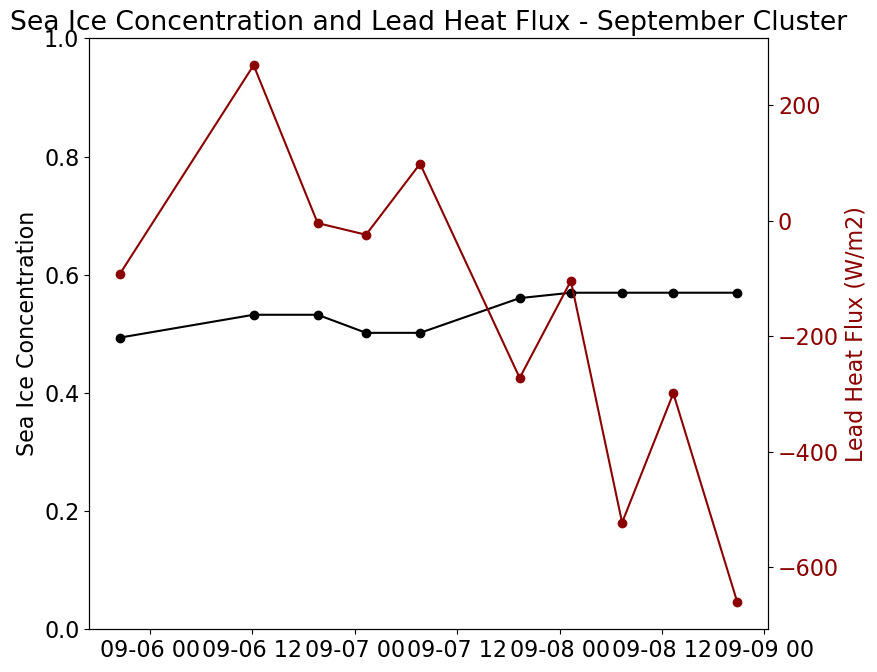

In [32]:
fig, ax = plt.subplots(figsize = (9,7))

ax.plot(data1_all_cluster09.datetimes, data1_all_cluster09.siconc, "-o", color = "black")
ax.set_ylabel("Sea Ice Concentration")
ax.set_ylim(0,1)

ax2col = "darkred"
ax2 = ax.twinx()
ax2.plot(data1_all_cluster09.datetimes, data1_all_cluster09.open_water_heatflux, "-o", color =ax2col)
ax2.set_ylabel("Lead Heat Flux (W/m2)", color=ax2col)
ax2.tick_params(axis='y', labelcolor=ax2col)

plt.title("Sea Ice Concentration and Lead Heat Flux - September Cluster")

plt.tight_layout()

In [33]:
data1_all_cluster09

,bath,bot,bot_ps,cycle,dates,dcycle,ddates,f,flag,heat_ps,...,surf,surf_ps,thickn_ps,types,datetimes,SC,max_ps_all,siconc,open_water_heatflux,surface_net_heat_flux
256,5214.00,585.756893,104.014849,541.0,733656.854167,NaN,NaN,-0.000121,0.0,-2.114038e+07,...,5.945133,5.945133,98.069715,3.0,2008-09-05 20:29:59.999997,True,-0.058398,0.493561,-92.104370,-46.645264
257,5293.25,785.243251,77.272941,542.0,733657.506944,NaN,NaN,-0.000122,0.0,-1.545967e+07,...,5.945111,5.945111,71.327830,3.0,2008-09-06 12:10:00.000004,True,-0.064719,0.532227,269.503662,126.066650
258,5287.00,603.537625,19.816327,543.0,733657.819444,NaN,NaN,-0.000122,0.0,-2.630977e+06,...,5.945100,5.945100,13.871227,3.0,2008-09-06 19:40:00.000004,True,-0.036680,0.532227,-4.070981,-1.904297
259,5229.00,619.343487,62.414834,544.0,733658.055556,NaN,NaN,-0.000122,0.0,-1.486996e+07,...,5.945092,5.945092,56.469742,3.0,2008-09-07 01:19:59.999996,True,-0.088725,0.501648,-24.275843,-12.097916
260,5178.25,607.487666,111.936676,545.0,733658.319444,NaN,NaN,-0.000122,0.0,-3.582474e+07,...,5.945083,5.945083,105.991593,3.0,2008-09-07 07:40:00.000004,True,-0.095137,0.501648,98.778687,49.226562
261,5112.25,605.510099,101.042597,546.0,733658.805556,NaN,NaN,-0.000122,0.0,-3.508008e+07,...,5.945067,5.945067,95.097531,3.0,2008-09-07 19:19:59.999996,True,-0.115537,0.560394,-272.367645,-119.734375
262,5130.75,753.647208,100.052083,547.0,733659.055556,NaN,NaN,-0.000122,0.0,-3.098453e+07,...,5.945058,5.945058,94.107025,3.0,2008-09-08 01:19:59.999996,True,-0.111438,0.569519,-104.113678,-44.818954
263,5139.75,720.077519,102.032671,548.0,733659.305556,NaN,NaN,-0.000122,0.0,-3.133145e+07,...,5.945050,5.945050,96.087622,3.0,2008-09-08 07:19:59.999996,True,-0.106170,0.569519,-523.011475,-225.146484
264,5133.50,696.377758,102.032525,549.0,733659.555556,NaN,NaN,-0.000122,0.0,-3.135228e+07,...,5.945041,5.945041,96.087484,3.0,2008-09-08 13:19:59.999996,True,-0.091118,0.569519,-299.022247,-128.723389
265,5045.50,556.103730,110.945370,550.0,733659.868056,NaN,NaN,-0.000122,0.0,-3.411357e+07,...,5.945030,5.945030,105.000339,3.0,2008-09-08 20:49:59.999996,True,-0.097460,0.569519,-661.306702,-284.679932


### Map - all Clusters

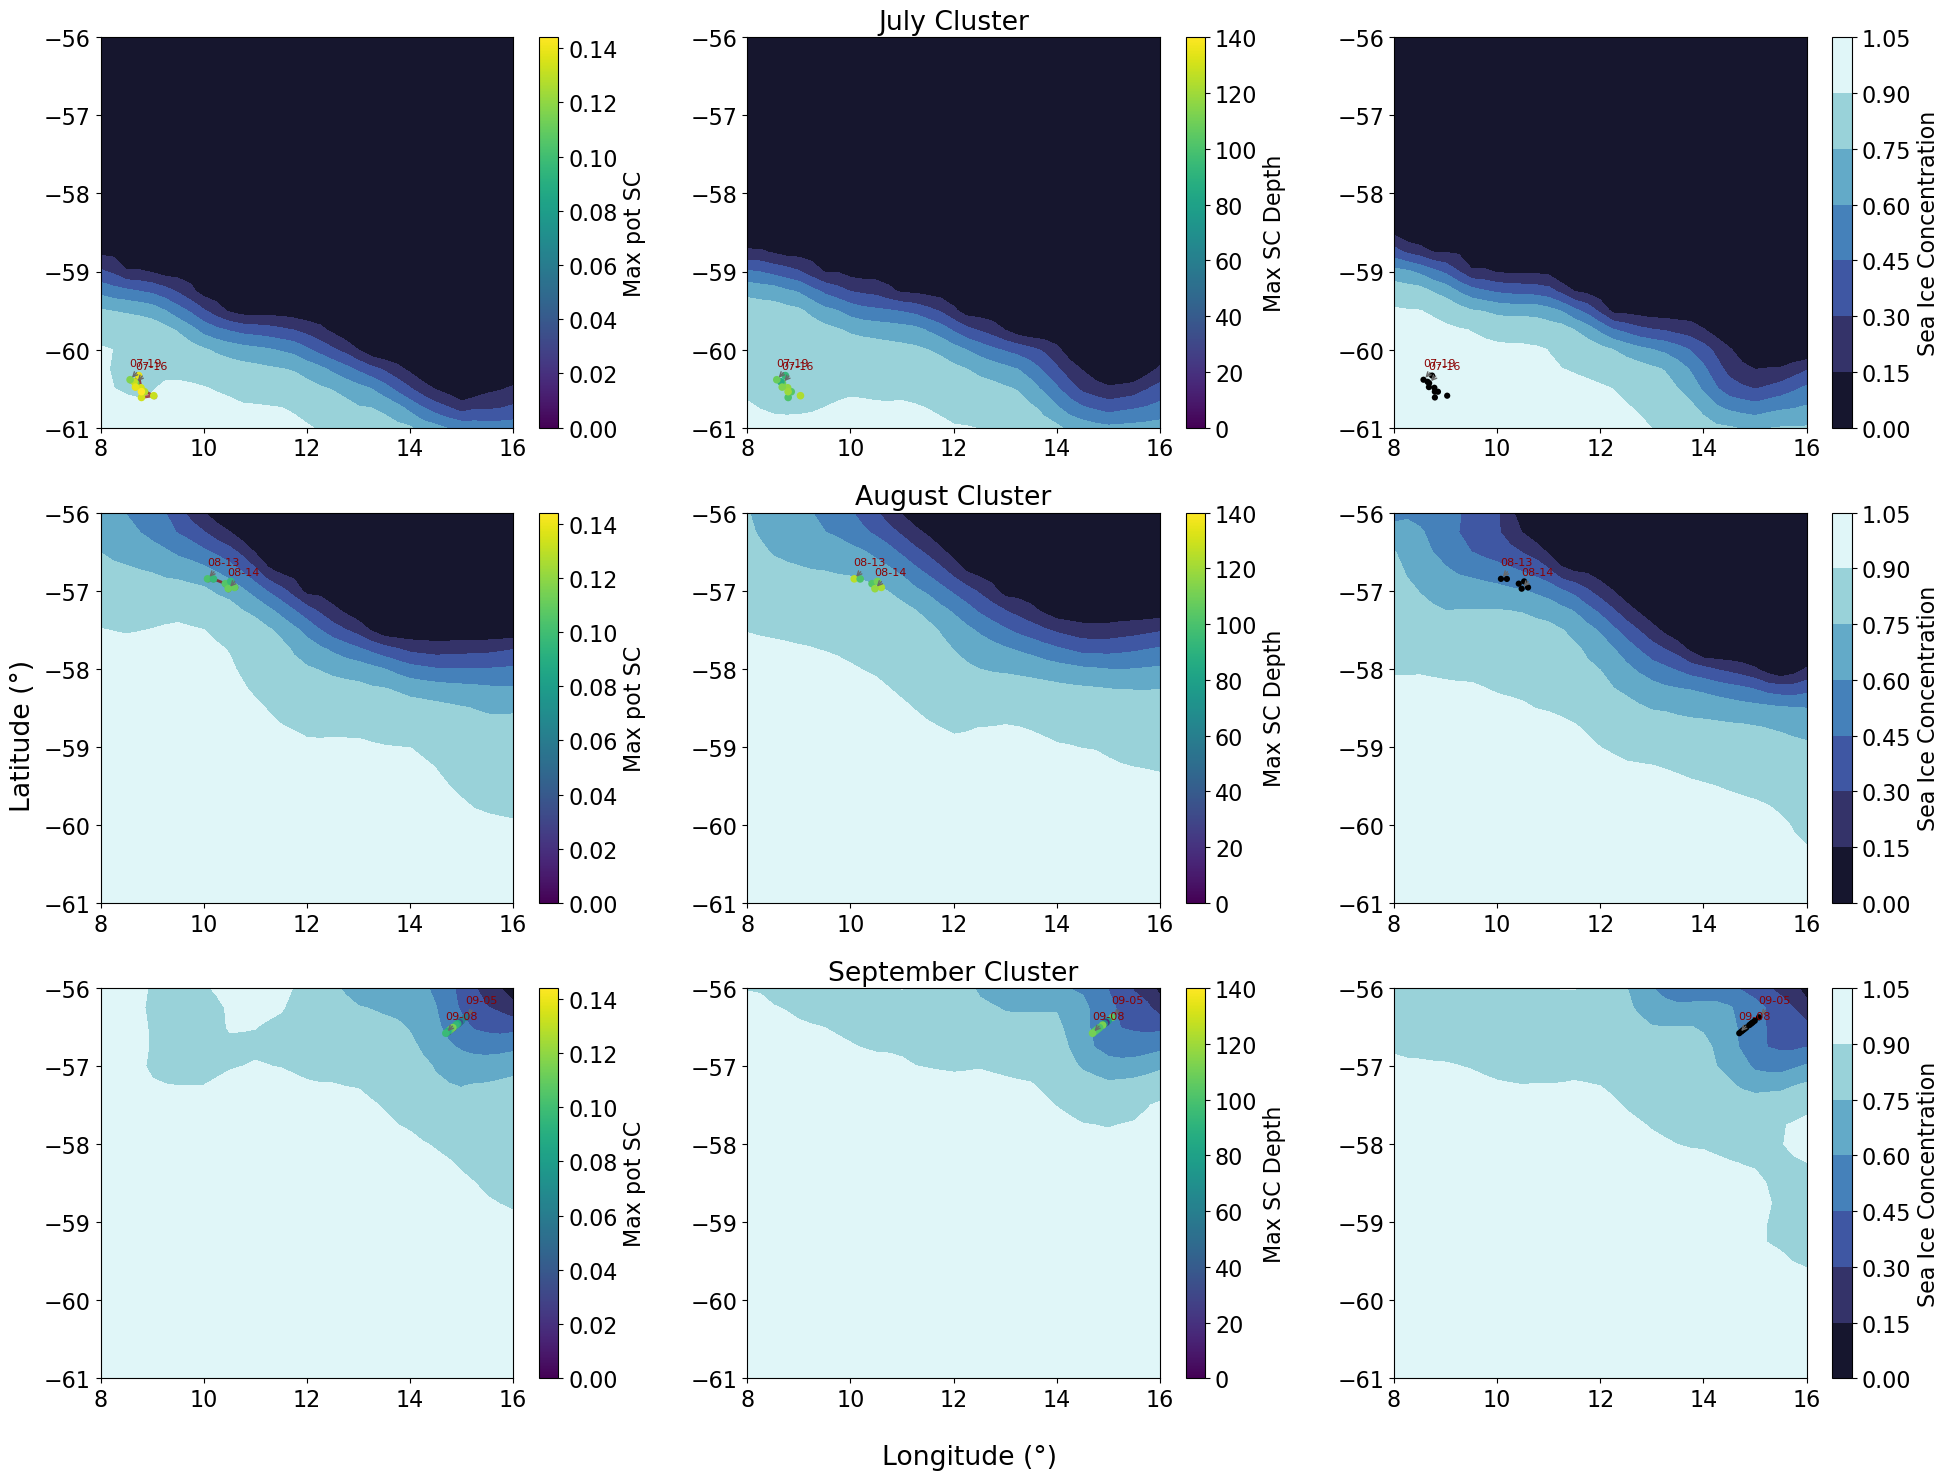

In [34]:
fig, axs = plt.subplots(3,3, figsize = (20,15))

for i in range(3): # loop through rows
    if i==0:
        data1_all_cluster = data1_all_cluster07
        df_seaice_cluster = df_seaice_cluster07
    elif i==1:
        data1_all_cluster = data1_all_cluster08
        df_seaice_cluster = df_seaice_cluster08
    elif i==2:
        data1_all_cluster = data1_all_cluster09
        df_seaice_cluster = df_seaice_cluster09

 
    X,Y = np.meshgrid(df_seaice_cluster.longitude, df_seaice_cluster.latitude)
    # first panel: sea ice start
    axs[i,0].contourf(X,Y, df_seaice_cluster.siconc.isel(time=0).values, cmap = cmo.ice, vmin = 0, vmax = 1)

    # Draw the path line
    axs[i,0].plot(data1_all_cluster['lon'], data1_all_cluster['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "darkred")    
    
    # Add scatter points with SC coloring
    scatter = axs[i,0].scatter(data1_all_cluster['lon'], data1_all_cluster['lat'], c=-data1_all_cluster["max_ps"], cmap='viridis', 
                          s=30, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 0.144)
    
    # Apply the formatter to the colorbar
    cbar = plt.colorbar(scatter)
    cbar.set_label('Max pot SC')

    row0 = data1_all_cluster.iloc[0,:]
    row_1 = data1_all_cluster.iloc[-1,:]
    x0,y0 = -0.5,10
    x_1,y_1 = -0.5,10
    for j in range(3):
            # Annotate first and last point
            axs[i,j].annotate(row0['datetimes'].strftime('%m-%d'), (row0['lon'], row0['lat']), 
                     textcoords="offset points", xytext=(x0,y0), ha='left', fontsize=8, zorder=4, color = "darkred", arrowprops=dict(arrowstyle='->', color='dimgrey'))

            axs[i,j].annotate(row_1['datetimes'].strftime('%m-%d'), (row_1['lon'], row_1['lat']), 
                     textcoords="offset points", xytext=(x_1,y_1), ha='left', fontsize=8, zorder=4, color = "darkred", arrowprops=dict(arrowstyle='->', color='dimgrey'))


    # middle panel: sea ice middle
    nt = len(df_seaice_cluster.time.values)
    axs[i,1].contourf(X,Y, df_seaice_cluster.siconc.isel(time=int(nt/2)).values, cmap = cmo.ice, vmin = 0, vmax = 1)
    # Add scatter points with SC depth coloring
    scatter1 = axs[i,1].scatter(data1_all_cluster['lon'], data1_all_cluster['lat'], c=data1_all_cluster["bot_ps"], cmap='viridis', 
                          s=30, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 140)
    
    # Apply the formatter to the colorbar
    cbar = plt.colorbar(scatter1)
    cbar.set_label('Max SC Depth')


    # last panel: sea ice end
    contourf = axs[i,2].contourf(X,Y, df_seaice_cluster.siconc.isel(time=-1).values, cmap = cmo.ice, vmin = 0, vmax = 1)
    # Apply the formatter to the colorbar
    cbar = plt.colorbar(contourf)
    cbar.set_label('Sea Ice Concentration')

    # Add scatter points without
    axs[i,2].scatter(data1_all_cluster['lon'], data1_all_cluster['lat'], c="black", 
                          s=20, edgecolors='none', zorder=3, label='Locations')
    


axs[0,1].set_title("July Cluster")
axs[1,1].set_title("August Cluster")
axs[2,1].set_title("September Cluster")


for ax in axs.flatten():
    ax.set_ylim(-61,-56)
    ax.set_xlim(8,16)
    
    
fig.supxlabel('Longitude (°)')
fig.supylabel('Latitude (°)')

    
plt.tight_layout()


### Map - all Clusters - improved

In [35]:
data1_all_cluster07.datetimes

127   2008-07-16 08:00:00.000003
128   2008-07-17 09:19:59.999999
129   2008-07-17 13:10:00.000001
130   2008-07-17 19:19:59.999996
131   2008-07-18 01:19:59.999996
132   2008-07-18 08:00:00.000003
133   2008-07-18 15:39:59.999998
134   2008-07-18 20:40:00.000001
135   2008-07-19 02:40:00.000001
136   2008-07-19 10:10:00.000001
Name: datetimes, dtype: datetime64[ns]

In [36]:
data1_all_cluster08.datetimes

205   2008-08-13 02:20:00.000002
206   2008-08-13 07:19:59.999996
207   2008-08-13 13:40:00.000004
208   2008-08-14 07:40:00.000004
209   2008-08-14 16:19:59.999996
210   2008-08-14 19:40:00.000004
Name: datetimes, dtype: datetime64[ns]

In [37]:
data1_all_cluster09.datetimes

256   2008-09-05 20:29:59.999997
257   2008-09-06 12:10:00.000004
258   2008-09-06 19:40:00.000004
259   2008-09-07 01:19:59.999996
260   2008-09-07 07:40:00.000004
261   2008-09-07 19:19:59.999996
262   2008-09-08 01:19:59.999996
263   2008-09-08 07:19:59.999996
264   2008-09-08 13:19:59.999996
265   2008-09-08 20:49:59.999996
Name: datetimes, dtype: datetime64[ns]

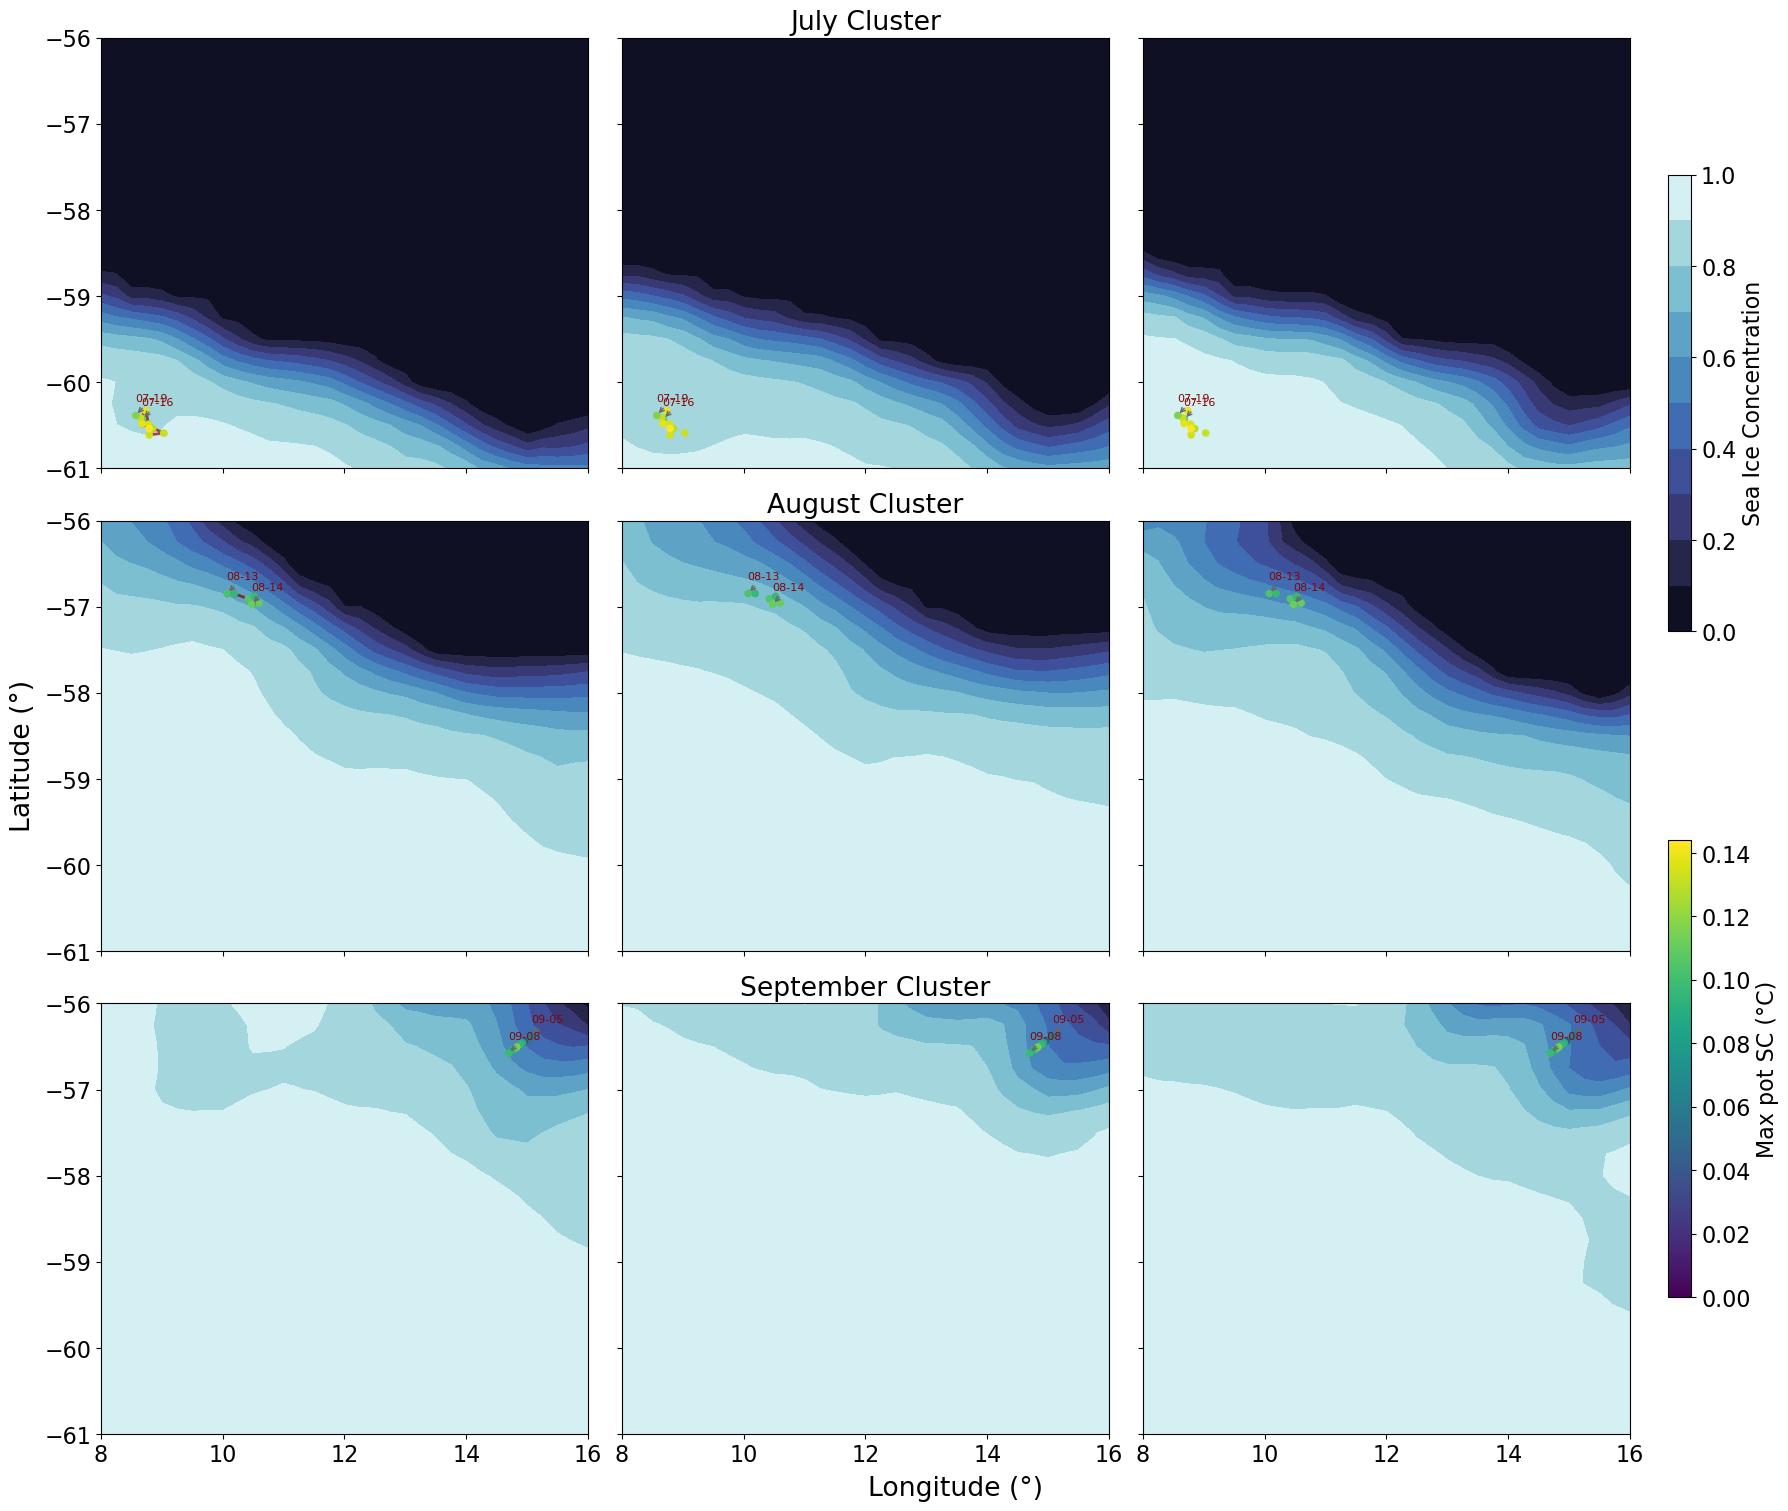

In [50]:
fig, axs = plt.subplots(3,3, figsize = (19,15), sharex = True, sharey = True, layout="constrained")

levels_siconc = np.linspace(0, 1,11) # plotting levels for sea ice

for i in range(3): # loop through rows
    if i==0:
        data1_all_cluster = data1_all_cluster07
        df_seaice_cluster = df_seaice_cluster07
    elif i==1:
        data1_all_cluster = data1_all_cluster08
        df_seaice_cluster = df_seaice_cluster08
    elif i==2:
        data1_all_cluster = data1_all_cluster09
        df_seaice_cluster = df_seaice_cluster09

    nprofiles = len(data1_all_cluster.datetimes)
    
 
    X,Y = np.meshgrid(df_seaice_cluster.longitude, df_seaice_cluster.latitude)
    
    # FIRST PANEL
    # sea ice start
    axs[i,0].contourf(X,Y, df_seaice_cluster.siconc.isel(time=0).values, cmap = cmo.ice, vmin = 0, vmax = 1, levels = levels_siconc)

    # Draw the path line
    axs[i,0].plot(data1_all_cluster['lon'], data1_all_cluster['lat'], '.-', linewidth=2, alpha=0.7, label='Movement Path', color = "darkred")    
    
    # Add scatter points with SC coloring
    scatter = axs[i,0].scatter(data1_all_cluster['lon'], data1_all_cluster['lat'], c=-data1_all_cluster["max_ps"], cmap='viridis', 
                          s=30, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 0.144)


    row0 = data1_all_cluster.iloc[0,:]
    row_1 = data1_all_cluster.iloc[-1,:]
    x0,y0 = -0.5,10
    x_1,y_1 = -0.5,10
    for j in range(3):
            # Annotate first and last point
            axs[i,j].annotate(row0['datetimes'].strftime('%m-%d'), (row0['lon'], row0['lat']), 
                     textcoords="offset points", xytext=(x0,y0), ha='left', fontsize=8, zorder=4, color = "darkred", arrowprops=dict(arrowstyle='->', color='dimgrey'))

            axs[i,j].annotate(row_1['datetimes'].strftime('%m-%d'), (row_1['lon'], row_1['lat']), 
                     textcoords="offset points", xytext=(x_1,y_1), ha='left', fontsize=8, zorder=4, color = "darkred", arrowprops=dict(arrowstyle='->', color='dimgrey'))


    # MIDDLE PANEL
    # sea ice middle
    nt = len(df_seaice_cluster.time.values)
    axs[i,1].contourf(X,Y, df_seaice_cluster.siconc.isel(time=int(nt/2)).values, cmap = cmo.ice, vmin = 0, vmax = 1, levels = levels_siconc)
    # Add scatter points with SC depth coloring
    scatter = axs[i,1].scatter(data1_all_cluster['lon'], data1_all_cluster['lat'], c=-data1_all_cluster["max_ps"], cmap='viridis', 
                          s=30, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 0.144)
    

    # LAST PANEL
    # sea ice end
    contourf = axs[i,2].contourf(X,Y, df_seaice_cluster.siconc.isel(time=-1).values, cmap = cmo.ice, vmin = 0, vmax = 1, levels = levels_siconc)

    # Add scatter points with SC depth coloring
    scatter = axs[i,2].scatter(data1_all_cluster['lon'], data1_all_cluster['lat'], c=-data1_all_cluster["max_ps"], cmap='viridis', 
                               s=30, edgecolors='none', zorder=3, label='Locations', vmin =0, vmax = 0.144)
   



# Plot sea ice colorbar
cbar_siconc = fig.colorbar(contourf, ax=axs[0:2, 2], shrink=0.5, anchor = (0,0.7)) # place the colorbar next to the upper two rows, anchored at 30% from top of top row
cbar_siconc.set_label('Sea Ice Concentration')


# SC colorbar
cbar_SC = fig.colorbar(scatter, ax=axs[1:3, 2], shrink=0.5, anchor = (0,0.3))
cbar_SC.set_label('Max pot SC (°C)')
    



axs[0,1].set_title("July Cluster")
axs[1,1].set_title("August Cluster")
axs[2,1].set_title("September Cluster")


for ax in axs.flatten():
    ax.set_ylim(-61,-56)
    ax.set_xlim(8,16)
    
    
fig.supxlabel('Longitude (°)')
fig.supylabel('Latitude (°)')


plt.show()


## Selected Profiles

Plot initial profiles from different clusters (T, S, SC)

In [51]:
cluster07_data2.keys()

dict_keys(['cp', 'def_pt0', 'def_pt0_err', 'def_t', 'def_t_err', 'dpth', 'dpth_mid', 'ds', 'dt', 'gamman', 'n2', 'prs', 'prs_err', 'prs_mid', 'pt0', 'pt0_err', 'rho', 's', 's_err', 'sigma0', 't', 't_err', 't_freeze', 't_freeze0', 't_freeze0_err', 't_freeze_err'])

Text(0.5, 0.98, 'Uncertainties')

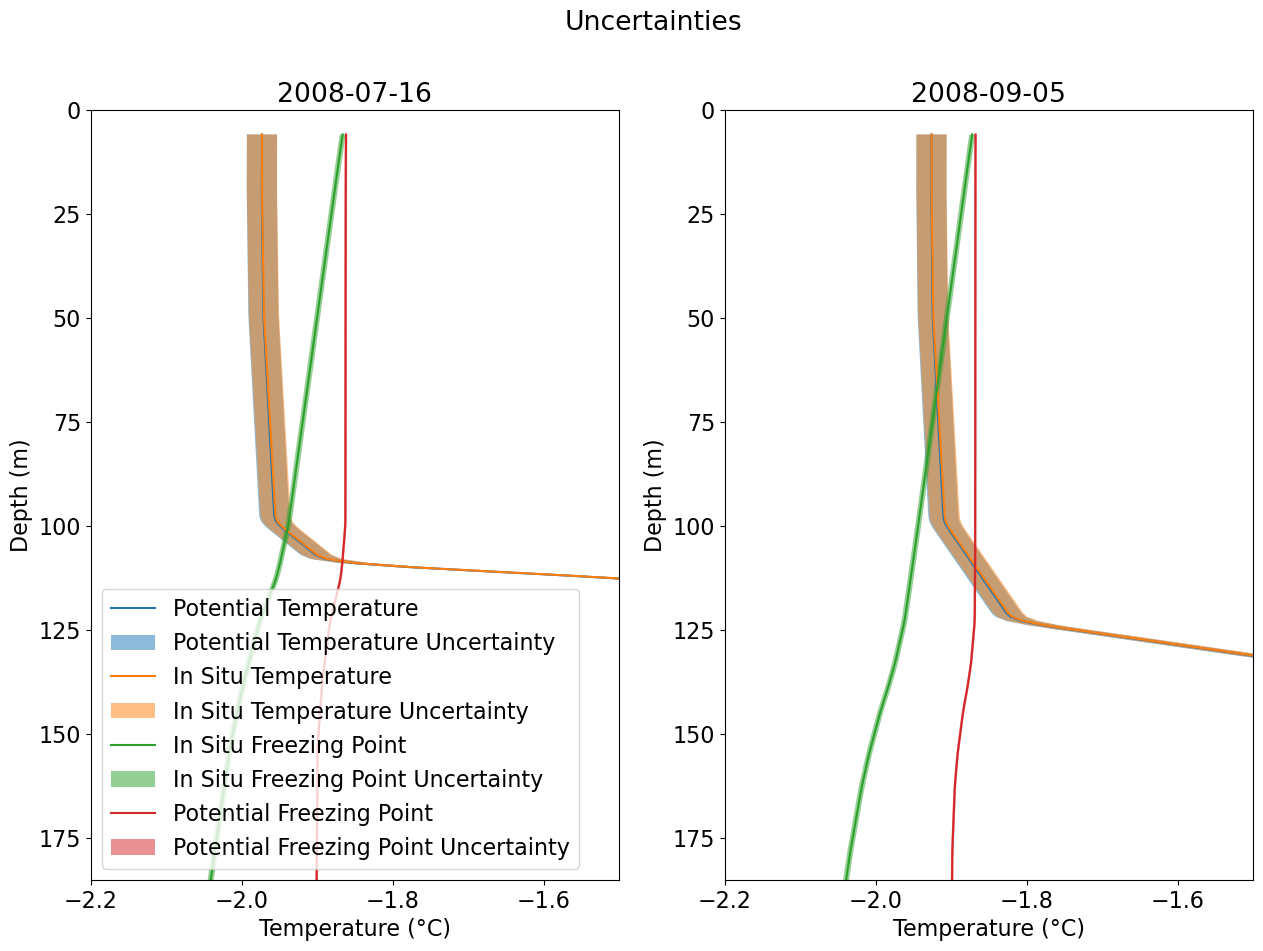

In [52]:
fig, ax = plt.subplots(1,2, figsize = (15,10))

# July
ax[0].plot(cluster07_data2["pt0"][:,0], cluster07_data2["dpth"][:,0], label = "Potential Temperature")
ax[0].fill_betweenx(cluster07_data2["dpth"][:,0], cluster07_data2["pt0"][:,0]-cluster07_data2["pt0_err"][:,0], cluster07_data2["pt0"][:,0]+cluster07_data2["pt0_err"][:,0], label = "Potential Temperature Uncertainty", alpha = 0.5)

ax[0].plot(cluster07_data2["t"][:,0], cluster07_data2["dpth"][:,0], label = "In Situ Temperature")
ax[0].fill_betweenx(cluster07_data2["dpth"][:,0], cluster07_data2["t"][:,0]-cluster07_data2["t_err"][:,0], cluster07_data2["t"][:,0]+cluster07_data2["t_err"][:,0], label = "In Situ Temperature Uncertainty", alpha = 0.5)

ax[0].plot(cluster07_data2["t_freeze"][:,0], cluster07_data2["dpth"][:,0], label = "In Situ Freezing Point")
ax[0].fill_betweenx(cluster07_data2["dpth"][:,0], cluster07_data2["t_freeze"][:,0]-cluster07_data2["t_freeze_err"][:,0], cluster07_data2["t_freeze"][:,0]+cluster07_data2["t_freeze_err"][:,0], label = "In Situ Freezing Point Uncertainty", alpha = 0.5)

ax[0].plot(cluster07_data2["t_freeze0"][:,0], cluster07_data2["dpth"][:,0], label = "Potential Freezing Point")
ax[0].fill_betweenx(cluster07_data2["dpth"][:,0], cluster07_data2["t_freeze0"][:,0]-cluster07_data2["t_freeze0_err"][:,0], cluster07_data2["t_freeze0"][:,0]+cluster07_data2["t_freeze0_err"][:,0], label = "Potential Freezing Point Uncertainty", alpha = 0.5)

# Sep 

ax[1].plot(cluster09_data2["pt0"][:,0], cluster09_data2["dpth"][:,0], label = "Potential Temperature")
ax[1].fill_betweenx(cluster09_data2["dpth"][:,0], cluster09_data2["pt0"][:,0]-cluster09_data2["pt0_err"][:,0], cluster09_data2["pt0"][:,0]+cluster09_data2["pt0_err"][:,0], label = "Potential Temperature Uncertainty", alpha = 0.5)

ax[1].plot(cluster09_data2["t"][:,0], cluster09_data2["dpth"][:,0], label = "In Situ Temperature")
ax[1].fill_betweenx(cluster09_data2["dpth"][:,0], cluster09_data2["t"][:,0]-cluster09_data2["t_err"][:,0], cluster09_data2["t"][:,0]+cluster09_data2["t_err"][:,0], label = "In Situ Temperature Uncertainty", alpha = 0.5)

ax[1].plot(cluster09_data2["t_freeze"][:,0], cluster09_data2["dpth"][:,0], label = "In Situ Freezing Point")
ax[1].fill_betweenx(cluster09_data2["dpth"][:,0], cluster09_data2["t_freeze"][:,0]-cluster09_data2["t_freeze_err"][:,0], cluster09_data2["t_freeze"][:,0]+cluster09_data2["t_freeze_err"][:,0], label = "In Situ Freezing Point Uncertainty", alpha = 0.5)

ax[1].plot(cluster09_data2["t_freeze0"][:,0], cluster09_data2["dpth"][:,0], label = "Potential Freezing Point")
ax[1].fill_betweenx(cluster09_data2["dpth"][:,0], cluster09_data2["t_freeze0"][:,0]-cluster09_data2["t_freeze0_err"][:,0], cluster09_data2["t_freeze0"][:,0]+cluster09_data2["t_freeze0_err"][:,0], label = "Potential Freezing Point Uncertainty", alpha = 0.5)

for a in ax:
    a.set_ylim(185,0)
    a.set_xlim(-2.2,-1.5)
    a.set_ylabel("Depth (m)")
    a.set_xlabel("Temperature (°C)")

ax[0].set_title(cluster07_data2_datetimes.iloc[0].strftime('%Y-%m-%d'))
ax[1].set_title(cluster09_data2_datetimes.iloc[0].strftime('%Y-%m-%d'))

ax[0].legend()

fig.suptitle("Uncertainties")


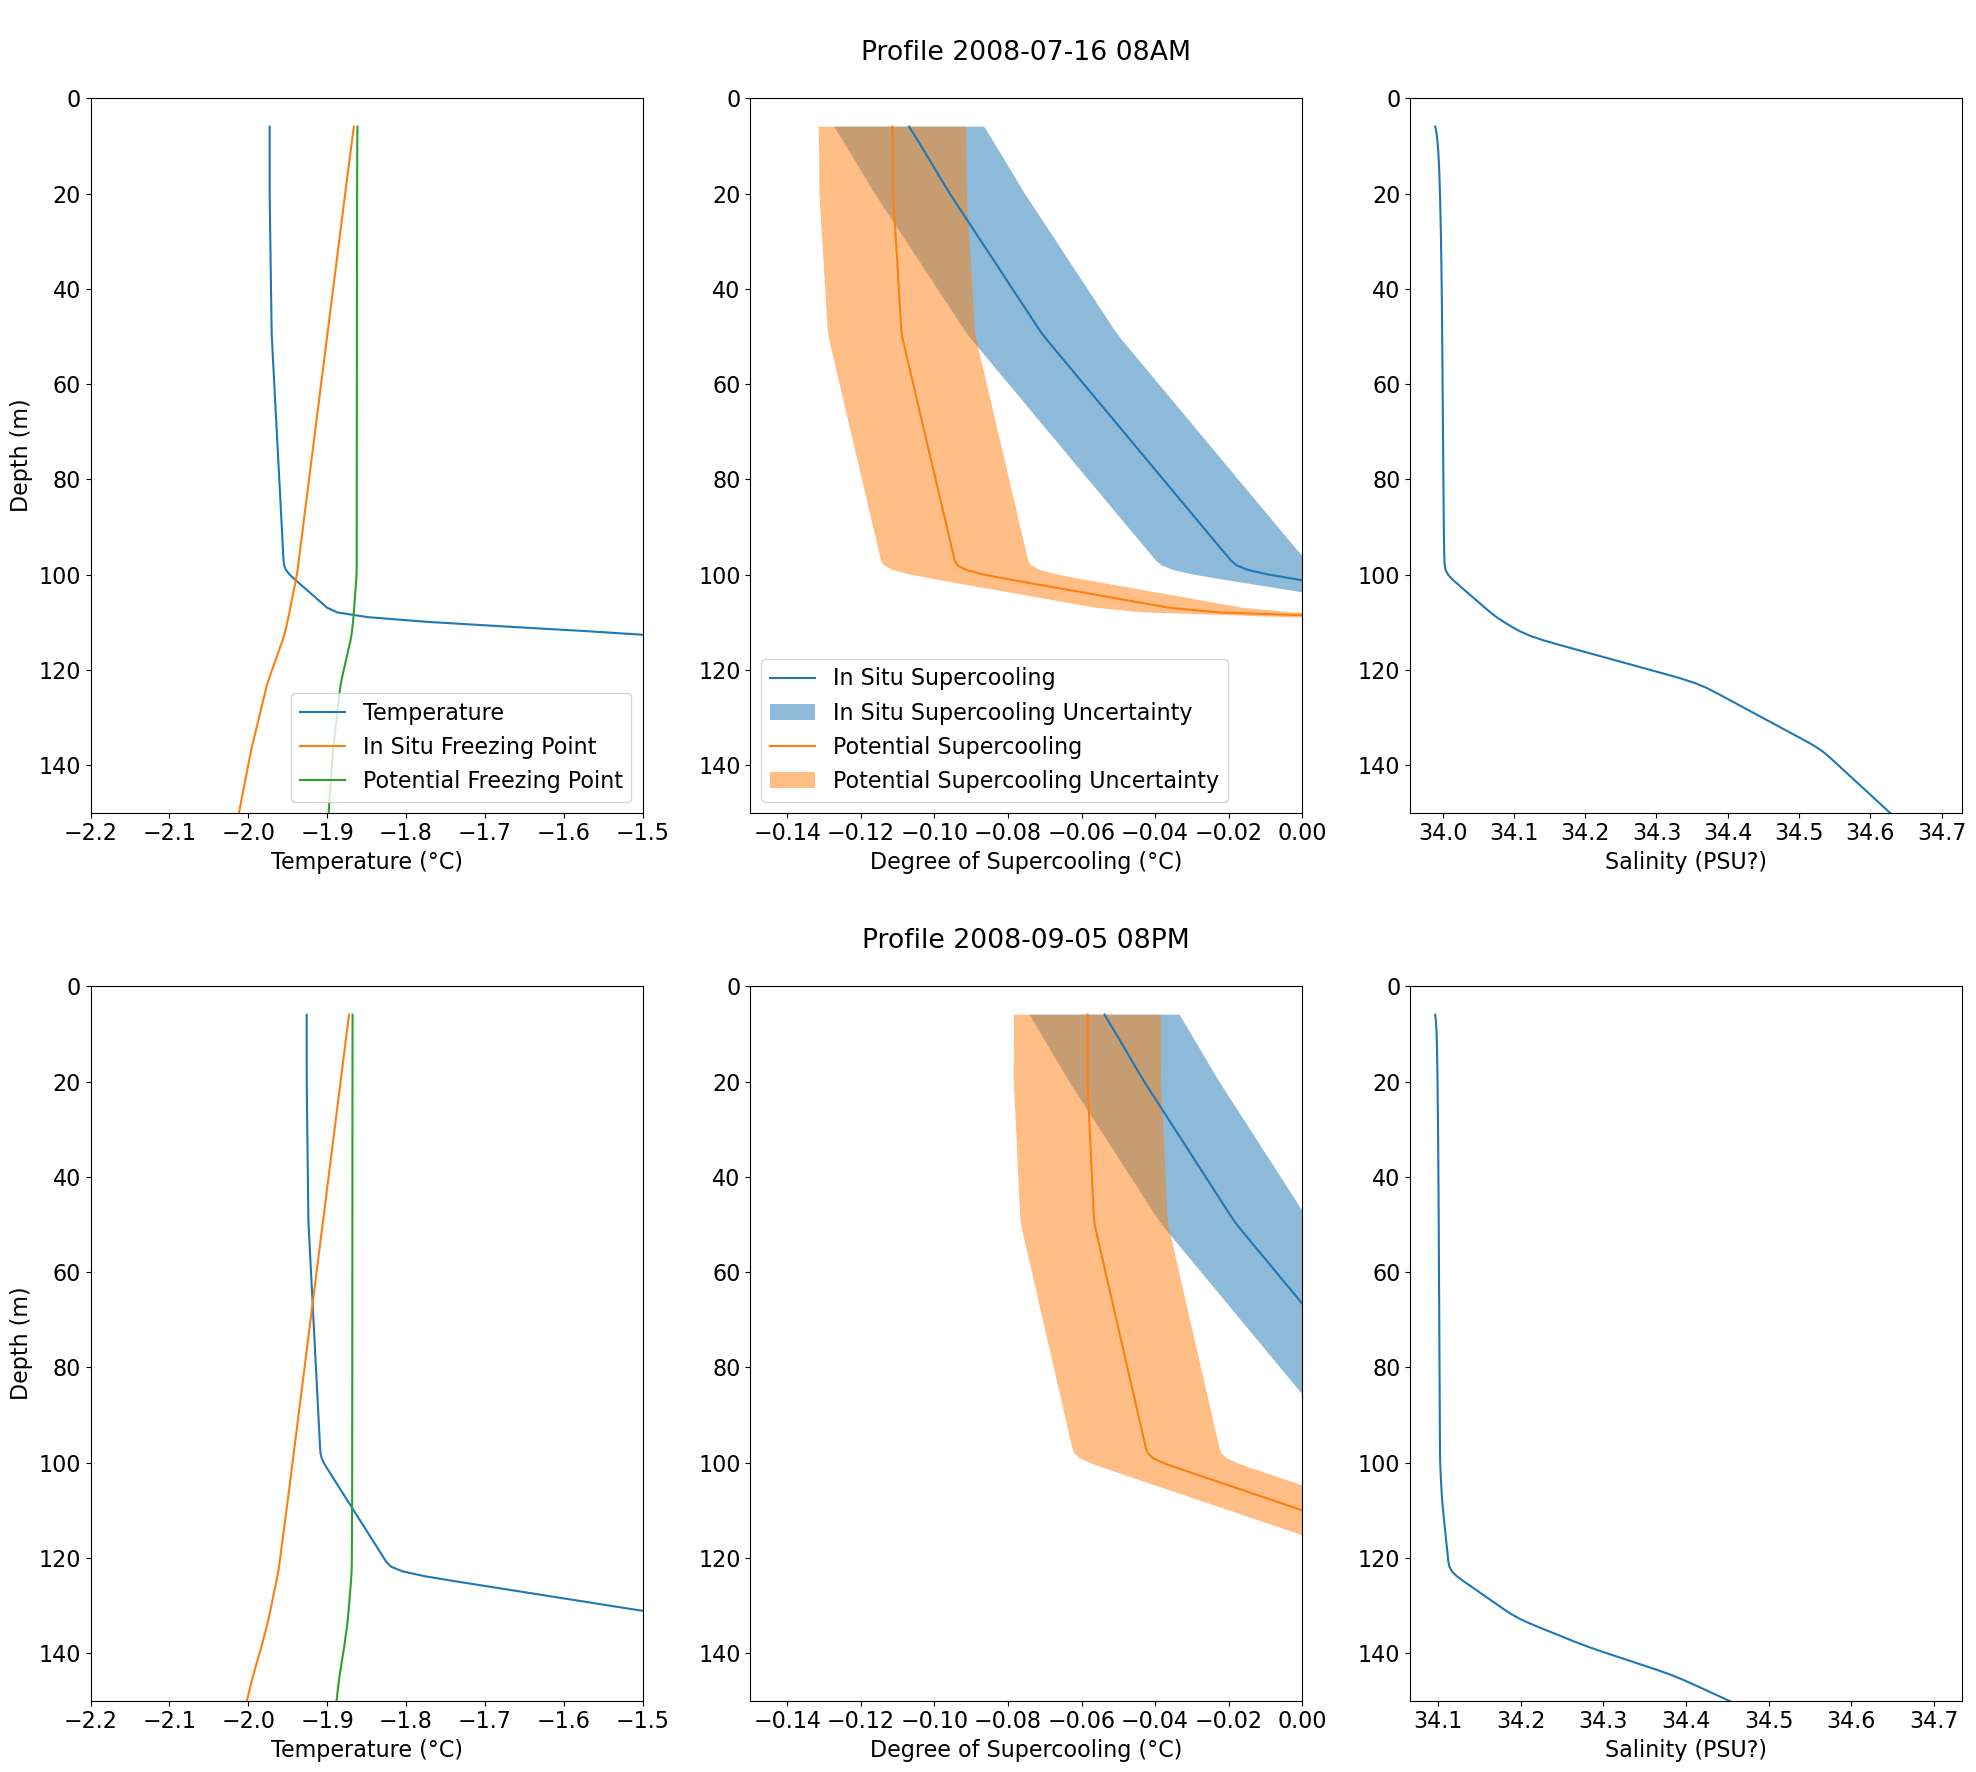

In [53]:
fig, axs = plt.subplots(2,3, figsize = (20,18))

for i in range(2):
    if i==0:
        cluster_data2 = cluster07_data2
        cluster_datetimes = cluster07_data2_datetimes
    elif i==1:
        cluster_data2 = cluster09_data2
        cluster_datetimes = cluster09_data2_datetimes       
        
    # T
    # axs[0,0].plot(cluster09_data2["pt0"][:,0], cluster09_data2["dpth"][:,0], label = "Potential Temperature")
    axs[i,0].plot(cluster_data2["t"][:,0], cluster_data2["dpth"][:,0], label = "Temperature")
    axs[i,0].plot(cluster_data2["t_freeze"][:,0], cluster_data2["dpth"][:,0], label = "In Situ Freezing Point")
    axs[i,0].plot(cluster_data2["t_freeze0"][:,0], cluster_data2["dpth"][:,0], label = "Potential Freezing Point")
    axs[i,0].set_xlim(-2.2,-1.5)
    axs[i,0].set_xlabel("Temperature (°C)")
    
    # fill supercooling
    # axs[0,0].fill_betweenx(y=cluster_data2["dpth"][:,0], x1=cluster_data2["t"][:,0], x2=cluster_data2["t_freeze"][:,0], where=(cluster_data2["t"][:,0]<cluster_data2["t_freeze"][:,0]), alpha = 0.5, label = "In Situ Supercooling")
    #axs[0,0].fill_betweenx(y=cluster_data2["dpth"][:,0], x1=cluster_data2["pt0"][:,0], x2=cluster_data2["t_freeze0"][:,0], where=(cluster_data2["pt0"][:,0]<cluster_data2["t_freeze0"][:,0]), alpha = 0.5, label = "Potential Supercooling")
    
    # SC
    axs[i,1].plot(cluster_data2["def_t"][:,0], cluster_data2["dpth"][:,0], label = "In Situ Supercooling")
    axs[i,1].fill_betweenx(cluster_data2["dpth"][:,0], cluster_data2["def_t"][:,0]-cluster_data2["def_t_err"][:,0], cluster_data2["def_t"][:,0]+cluster_data2["def_t_err"][:,0], label = "In Situ Supercooling Uncertainty", alpha = 0.5)
    axs[i,1].plot(cluster_data2["def_pt0"][:,0], cluster_data2["dpth"][:,0], label = "Potential Supercooling")
    axs[i,1].fill_betweenx(cluster_data2["dpth"][:,0], cluster_data2["def_pt0"][:,0]-cluster_data2["def_pt0_err"][:,0], cluster_data2["def_pt0"][:,0]+cluster_data2["def_pt0_err"][:,0], label = "Potential Supercooling Uncertainty", alpha = 0.5)
    axs[i,1].set_xlim(-0.15,0)
    axs[i,1].set_xlabel("Degree of Supercooling (°C)")
    
    # S
    axs[i,2].plot(cluster_data2["s"][:,0], cluster_data2["dpth"][:,0], label = "Salinity")
    axs[i,2].set_xlabel("Salinity (PSU?)")
    
    # depth
    axs[i,0].set_ylabel("Depth (m)")

    axs[i,1].set_title("\nProfile "+cluster_datetimes.iloc[0].strftime('%Y-%m-%d %I%p')+"\n")

# set depth axis properties
for ax in axs.flat:
    ax.set_ylim(150, 0)
    


axs[0,0].legend()
axs[0,1].legend()

plt.tight_layout()


## Sea Ice vs SC

In [54]:
# correlations:
cor = data1_9900109_all_df[["siconc", "max_ps_all", "open_water_heatflux", "bot_ps","surface_net_heat_flux"]].corr()
cor_onlySC = data1_9900109_all_df[["siconc", "max_ps", "open_water_heatflux", "bot_ps", "surface_net_heat_flux"]].corr()
print(cor)
print("\nExclude data with no supercooling:")
print(cor_onlySC)

print(f"\n=> Sea Ice concentration can predict if there is SC (r={cor.loc["siconc","max_ps_all"]:.2f}), but not well how strong it will be (r={cor_onlySC.loc["siconc","max_ps"]:.2f})")

                         siconc  max_ps_all  open_water_heatflux    bot_ps  \
siconc                 1.000000   -0.794075            -0.283904  0.233909   
max_ps_all            -0.794075    1.000000             0.256587 -0.511458   
open_water_heatflux   -0.283904    0.256587             1.000000 -0.149213   
bot_ps                 0.233909   -0.511458            -0.149213  1.000000   
surface_net_heat_flux  0.272511   -0.173717             0.658095 -0.033809   

                       surface_net_heat_flux  
siconc                              0.272511  
max_ps_all                         -0.173717  
open_water_heatflux                 0.658095  
bot_ps                             -0.033809  
surface_net_heat_flux               1.000000  

Exclude data with no supercooling:
                         siconc    max_ps  open_water_heatflux    bot_ps  \
siconc                 1.000000 -0.521801            -0.283904  0.233909   
max_ps                -0.521801  1.000000             0.19814

In [55]:
# correlation between all sea ice conc and max SC in my study region in my study period from this SEAL
r, p_value = sp.stats.pearsonr(data1_9900109_all_df["max_ps_all"], data1_9900109_all_df["siconc"])

print(f"Pearson r: {r:.2f}")
print(f"P-value: {p_value}")

Pearson r: -0.79
P-value: 3.436842626577533e-61


In [41]:
# exclude profiles without supercooling
r, p_value = sp.stats.pearsonr(data1_9900109_all_df["max_ps_all"][data1_9900109_all_df["SC"]==True], data1_9900109_all_df["siconc"][data1_9900109_all_df["SC"]==True])

print(f"Pearson r: {r:.2f}")
print(f"P-value: {p_value}")

Pearson r: -0.52
P-value: 3.467562804897549e-13


In [42]:
# point biserial correlation coefficient for the occurence of supercooling
r, p_value = sp.stats.pointbiserialr(data1_9900109_all_df["SC"], data1_9900109_all_df["siconc"])
print(f"Point-Biserial r: {r:.2f}, P-value: {p_value}")

Point-Biserial r: 0.72, P-value: 3.4398174991935218e-46


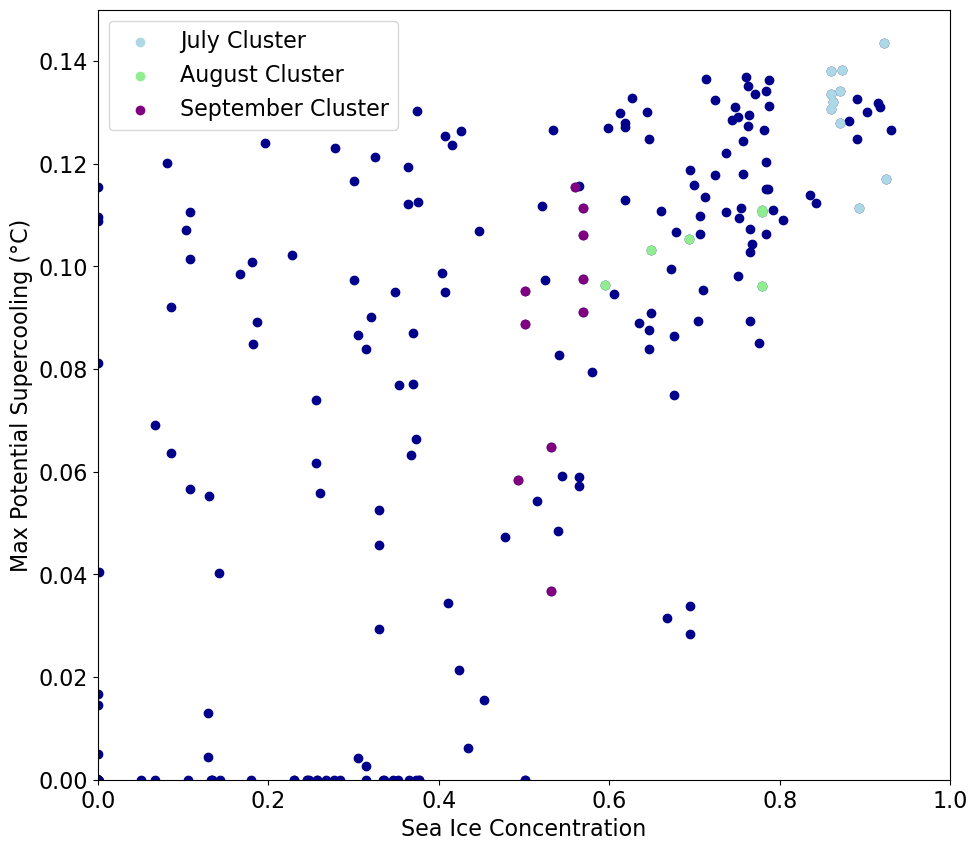

In [43]:
fig, ax = plt.subplots(figsize = (11,10))

# all profiles
ax.scatter(data1_9900109_all_df.siconc,-data1_9900109_all_df.max_ps_all, color = "darkblue")
# july cluster
ax.scatter(data1_all_cluster07.siconc,-data1_all_cluster07.max_ps_all, color = "lightblue", label = "July Cluster")
# august cluster
ax.scatter(data1_all_cluster08.siconc,-data1_all_cluster08.max_ps_all, color = "lightgreen", label = "August Cluster")
# sep cluster
ax.scatter(data1_all_cluster09.siconc,-data1_all_cluster09.max_ps_all, color = "purple", label = "September Cluster")


ax.set_xlim(0,1)
ax.set_ylim(0, 0.15)

ax.set_xlabel("Sea Ice Concentration")
ax.set_ylabel("Max Potential Supercooling (°C)")
ax.legend()
#ax.vlines(0.51,0,-0.14)

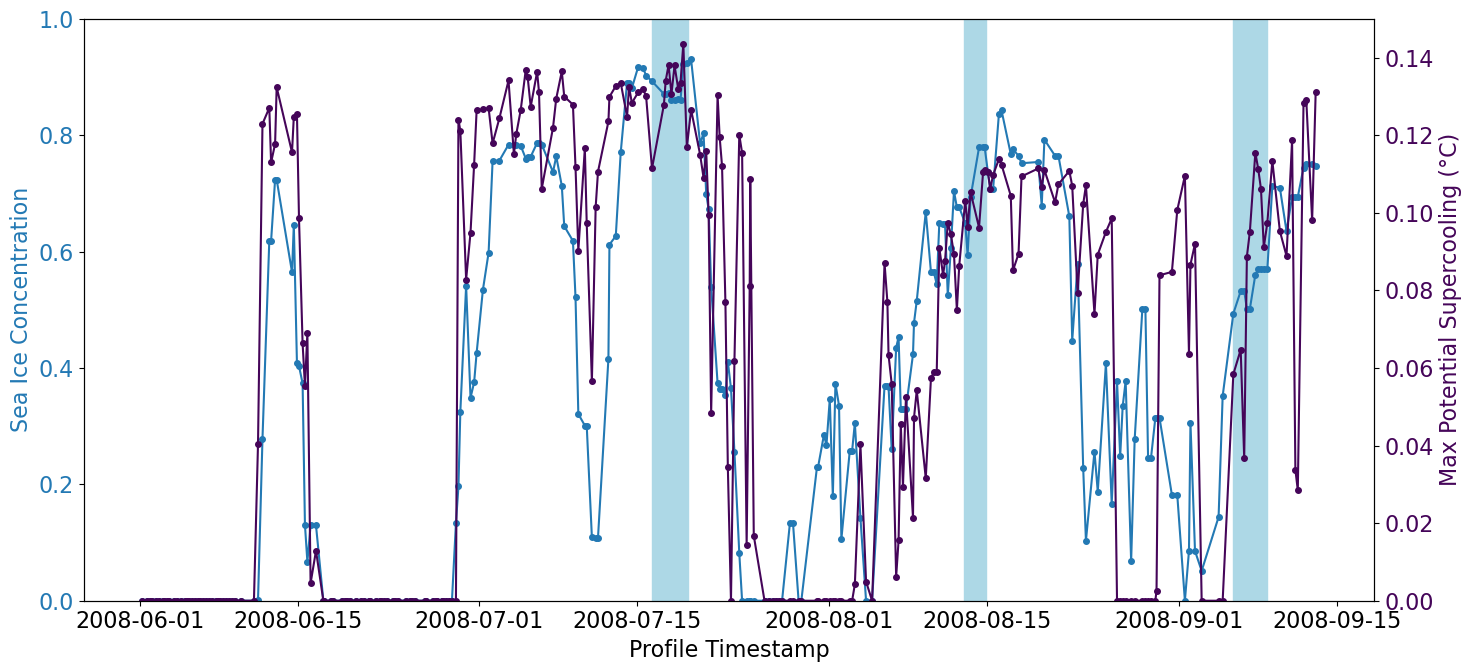

In [44]:
fig, ax = plt.subplots(figsize = (15,7))

col_sic = "#2379b4"
col_SC = "#450559"

# plot sea ice concentration
ax.plot(data1_9900109_all_df.datetimes, data1_9900109_all_df.siconc, "-o", color = col_sic, markersize=4, label = "Sea Ice Concentration")

# plot max pot SC
ax2 = ax.twinx()
ax2.plot(data1_9900109_all_df.datetimes, -data1_9900109_all_df.max_ps_all, "-o", color = col_SC, markersize=4, label = "Max Potential Supercooling")

# fill cluster time periods
ax.fill_between([start_date07, end_date07],[0,0],[1,1], color = "lightblue", label = "Clusters") 
ax.fill_between([start_date08, end_date08],[0,0],[1,1], color = "lightblue") 
ax.fill_between([start_date09, end_date09],[0,0],[1,1], color = "lightblue") 


ax.set_ylim(0,1)
ax2.set_ylim(0, 0.15)

ax.set_ylabel("Sea Ice Concentration", color = col_sic)
ax2.set_ylabel("Max Potential Supercooling (°C)", color = col_SC)

ax.set_xlabel("Profile Timestamp")

ax.tick_params(axis='y', labelcolor=col_sic)
ax2.tick_params(axis='y', labelcolor=col_SC)

# ask matplotlib for the plotted objects and their labels
lines, labels = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
# ax2.legend(lines + lines2, labels + labels2)

plt.tight_layout()

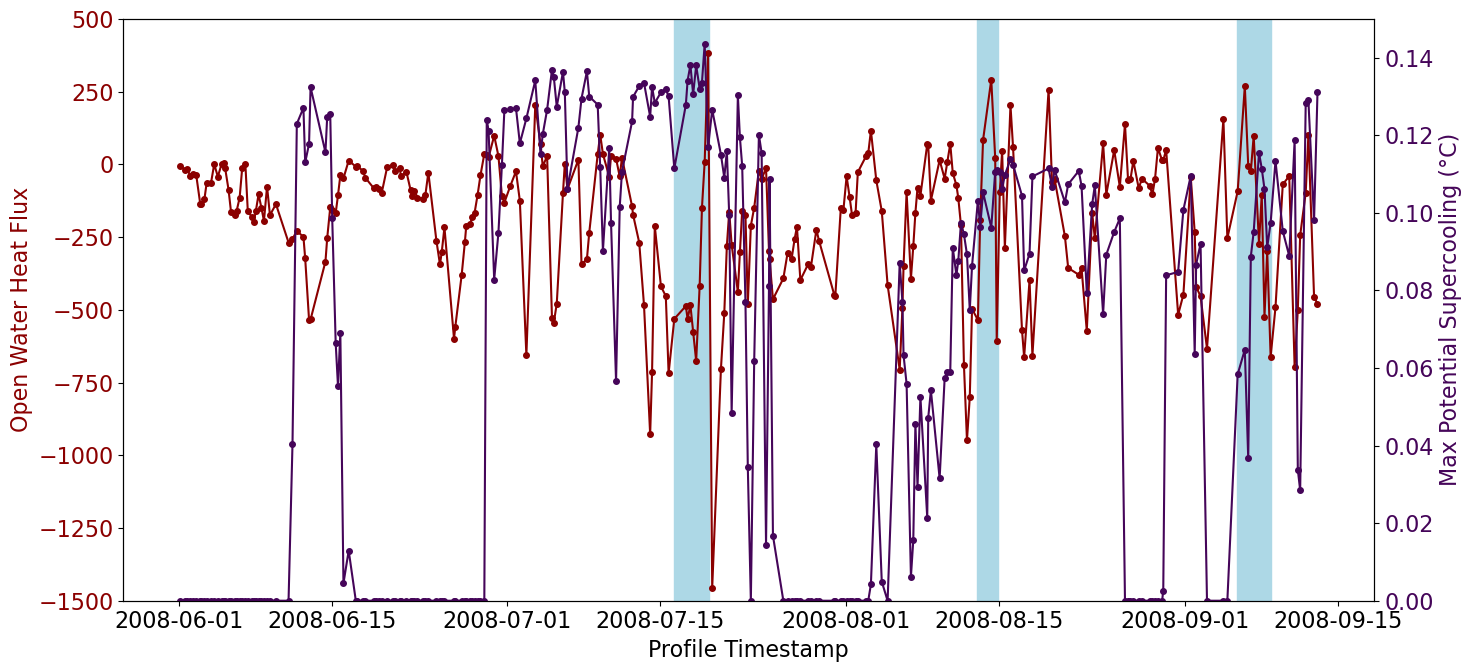

In [45]:
fig, ax = plt.subplots(figsize = (15,7))

col_heat = "darkred"
col_SC = "#450559"

# plot lead heat flux
ax.plot(data1_9900109_all_df.datetimes, data1_9900109_all_df.open_water_heatflux, "-o", color = col_heat, markersize=4)
ax.set_ylim(-1500, 500)

# plot max pot SC
ax2 = ax.twinx()
ax2.plot(data1_9900109_all_df.datetimes, -data1_9900109_all_df.max_ps_all, "-o", color = col_SC, markersize=4)
ax2.set_ylim(0, 0.15)

# fill cluster time periods
ax.fill_between([start_date07, end_date07],[500,500],[-1500,-1500], color = "lightblue", label = "July Cluster") 
ax.fill_between([start_date08, end_date08],[500,500],[-1500,-1500], color = "lightblue", label = "July Cluster") 
ax.fill_between([start_date09, end_date09],[500,500],[-1500,-1500], color = "lightblue", label = "July Cluster") 

ax.set_ylabel("Open Water Heat Flux", color = col_heat)
ax2.set_ylabel("Max Potential Supercooling (°C)", color = col_SC)

ax.set_xlabel("Profile Timestamp")

ax.tick_params(axis='y', labelcolor=col_heat)
ax2.tick_params(axis='y', labelcolor=col_SC)

plt.tight_layout()

## Max Supercooling Degree vs Max Supercooling Depth

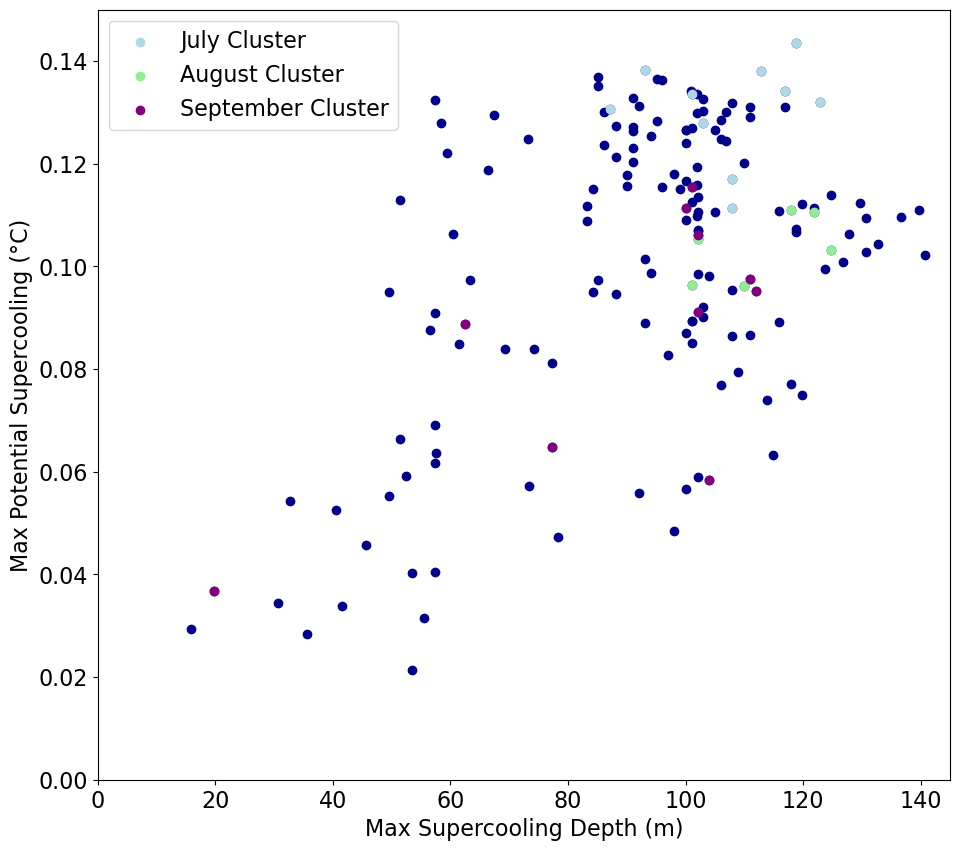

In [46]:
fig, ax = plt.subplots(figsize = (11,10))

# all profiles
ax.scatter(data1_9900109_all_df.bot_ps,-data1_9900109_all_df.max_ps_all, color = "darkblue")
# july cluster
ax.scatter(data1_all_cluster07.bot_ps,-data1_all_cluster07.max_ps_all, color = "lightblue", label = "July Cluster")
# august cluster
ax.scatter(data1_all_cluster08.bot_ps,-data1_all_cluster08.max_ps_all, color = "lightgreen", label = "August Cluster")
# sep cluster
ax.scatter(data1_all_cluster09.bot_ps,-data1_all_cluster09.max_ps_all, color = "purple", label = "September Cluster")


ax.set_xlim(0,145)
ax.set_ylim(0, 0.15)
ax.set_xlabel("Max Supercooling Depth (m)")
ax.set_ylabel("Max Potential Supercooling (°C)")
ax.legend()
#ax.vlines(0.51,0,-0.14)